In [ ]:
## Objetivo do Projeto

# Description : e-commerce transactions
# Evaluation:  area under the ROC curve. Queremos reduzir os Falsos Negativos

#Questions

#I will start exploring based on Categorical Features and Transaction Amounts. The aim is answer some questions like:

#    What type of data we have on our data?
#    How many cols, rows, missing values we have?
#    Whats the target distribution?
#    What's the Transactions values distribution of fraud and no fraud transactions?
#    We have predominant fraudulent products?
#    What features or target shows some interesting patterns?
#    And a lot of more questions that will raise trought the exploration.


## Importar as Bibliotecas

In [2]:
import gc
import datetime
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
# Remove warnings
import warnings
warnings.filterwarnings('ignore')

## Carregar e ajustar os Datasets

In [2]:
treino_id = pd.read_csv('dados/train_identity.csv')
treino_transacoes = pd.read_csv('dados/train_transaction.csv')
teste_id = pd.read_csv('dados/test_identity.csv')
teste_transacoes = pd.read_csv('dados/test_transaction.csv')

In [3]:
# As colunas no dataset de treino estavam com "_" e no dataset de teste estavam "-". Precisei ajeitar.
teste_id.columns = [x.replace('-','_') for x in teste_id.columns]

In [4]:
# Juntamos os datasets que continham os ids das transacoes com as transocoes em um unico dataset. Crie uma variavel "treino"
# para identificar os datasets, pois, para fazer a limpeza vou unir ambos.
# Train
train = pd.merge(treino_transacoes, treino_id, on='TransactionID', how='left')
train['treino'] = True
del treino_id, treino_transacoes
# Test
test = pd.merge(teste_transacoes, teste_id, on='TransactionID', how='left')
test['treino'] = False
test['isFraud'] = None
del teste_id, teste_transacoes
# All Data
all_data = pd.concat([train, test])
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1097231 entries, 0 to 506690
Columns: 435 entries, TransactionID to treino
dtypes: bool(1), float64(399), int64(3), object(32)
memory usage: 3.6+ GB


In [5]:
del train, test

## Data Cleaning

### Checking Missing Values

In [6]:
all_data.isnull().sum().sort_values(ascending=False) / len(all_data)

id_24             0.991354
id_25             0.990730
id_26             0.990695
id_07             0.990691
id_08             0.990691
                    ...   
card1             0.000000
ProductCD         0.000000
TransactionAmt    0.000000
TransactionDT     0.000000
treino            0.000000
Length: 435, dtype: float64

#### Dropping Missing Values

In [7]:
# Variaveis com valores missing maior que 28% seram excluidas.
drop_null_cols = [col for col in all_data.columns if all_data[col].isnull().sum() / all_data.shape[0] >= 0.28 and col != 'isFraud']
all_data.drop(drop_null_cols, axis=1, inplace=True)

#### Analisando Variáveis Numéricas p/ o Input de Dados

In [8]:
all_data.select_dtypes(exclude=(['O','bool'])).isnull().sum().sort_values(ascending=False)/ len(all_data)

V47               0.224039
V38               0.224039
V48               0.224039
V52               0.224039
V51               0.224039
                    ...   
C14               0.000003
TransactionDT     0.000000
card1             0.000000
TransactionAmt    0.000000
TransactionID     0.000000
Length: 196, dtype: float64

In [9]:
all_data.select_dtypes(exclude=(['O','bool'])).describe()

,TransactionID,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
count,1.097231e+06,1.097231e+06,1.097231e+06,1.097231e+06,1.079644e+06,1.092664e+06,1.088425e+06,965916.000000,965916.000000,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.092483e+06,1.097228e+06,1.089931e+06,851458.000000,1.008664e+06,996049.000000,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.089931e+06,1.089931e+06,1.089931e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06,1.097216e+06
mean,3.575333e+06,1.640384e+07,1.348879e+02,9.925744e+03,3.630998e+02,1.533556e+02,1.996868e+02,291.241913,86.765369,1.224565e+01,1.316624e+01,1.569227e-02,3.304229e+00,5.290377e+00,8.047716e+00,2.308044e+00,3.643492e+00,4.541059e+00,3.656317e+00,8.968402e+00,3.417374e+00,3.036952e+01,7.274049e+00,1.007141e+02,157.700888,1.415345e+02,185.152096,5.646614e-01,5.997874e-01,9.996698e-01,1.314645e-01,1.326979e-01,1.956396e-01,1.972349e-01,8.384751e-01,8.662927e-01,1.885285e-01,1.921286e-01,1.040034e+00,1.0

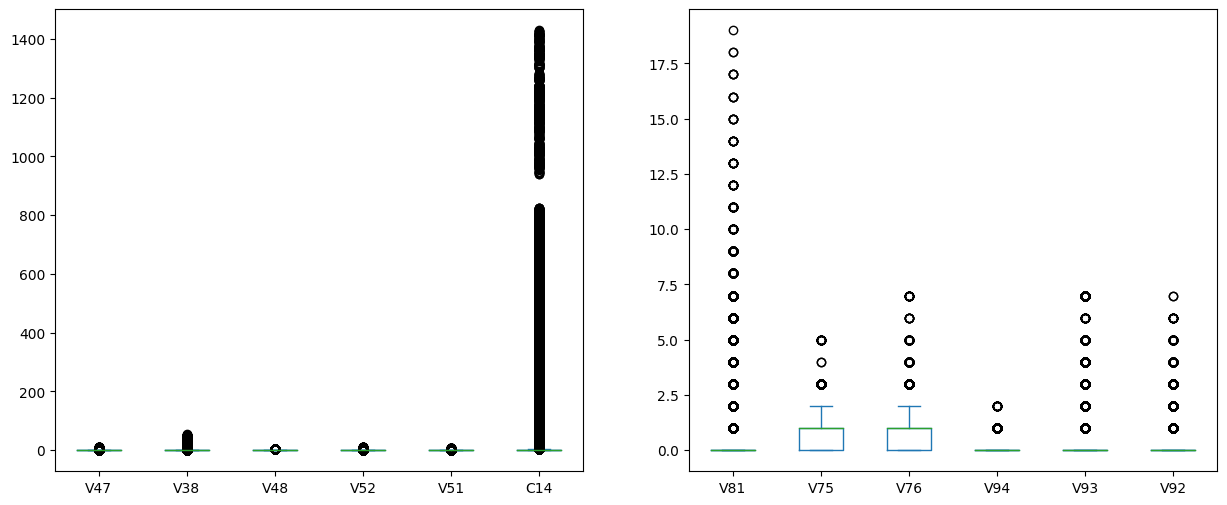

In [10]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))
all_data[['V47', 'V38', 'V48', 'V52', 'V51', 'C14']].plot.box(ax=ax1)
all_data[['V81', 'V75', 'V76', 'V94', 'V93', 'V92']].plot.box(ax=ax2)
plt.show()

Obs: Variáveis com muitos valores outliers.

#### Analisando Variáveis Categóricas

In [11]:
all_data.select_dtypes(include=(['O','bool'])).isnull().sum().sort_values(ascending=False)/ len(all_data)

isFraud          0.461791
P_emaildomain    0.149146
card4            0.004250
card6            0.004172
ProductCD        0.000000
treino           0.000000
dtype: float64

In [12]:
all_data.select_dtypes(include=(['O','bool'])).describe()

,isFraud,ProductCD,card4,card6,P_emaildomain,treino
count,590540,1097231,1092568,1092653,933583,1097231
unique,2,5,4,4,60,2
top,0,W,visa,debit,gmail.com,True
freq,569877,800657,719649,824959,435803,590540


In [13]:
all_data['ProductCD'].value_counts(dropna=False, normalize=True)[:10]

ProductCD
W    0.729707
C    0.125575
R    0.066846
H    0.056868
S    0.021004
Name: proportion, dtype: float64

In [14]:
all_data['card4'].value_counts(dropna=False, normalize=True)

card4
visa                0.655877
mastercard          0.316602
american express    0.014590
discover            0.008680
NaN                 0.004250
Name: proportion, dtype: float64

In [15]:
all_data['card6'].value_counts(dropna=False, normalize=True)

card6
debit              0.751855
credit             0.243930
NaN                0.004172
debit or credit    0.000027
charge card        0.000015
Name: proportion, dtype: float64

In [16]:
all_data['P_emaildomain'].value_counts(dropna=False, normalize=True)[:10]

P_emaildomain
gmail.com        0.397184
yahoo.com        0.166587
NaN              0.149146
hotmail.com      0.078059
anonymous.com    0.064765
aol.com          0.047699
comcast.net      0.013191
icloud.com       0.011225
outlook.com      0.009054
att.net          0.006969
Name: proportion, dtype: float64

#### Impute nos Valores Faltantes

In [17]:
# Variáveis Numéricas
for col in all_data.select_dtypes(exclude=['O', 'bool']):
    all_data[col] = all_data[col].fillna(all_data[col].median())

In [18]:
# Variáveis Categóricas

# card4
all_data.card4.fillna("NoInf", inplace=True)

# card6
all_data.card6.fillna("NoInf", inplace=True)

# P_emaildomain
all_data.loc[all_data['P_emaildomain'].isin(['gmail.com', 'gmail']),'P_emaildomain'] = 'Google'

all_data.loc[all_data['P_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                         'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                         'yahoo.es']), 'P_emaildomain'] = 'Yahoo'

all_data.loc[all_data['P_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                         'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                         'outlook.es', 'live.com', 'live.fr',
                                         'hotmail.fr']), 'P_emaildomain'] = 'Microsoft'

all_data.loc[all_data.P_emaildomain.isin(all_data.P_emaildomain.value_counts()[all_data.P_emaildomain.value_counts() <= 8000 ].index), 'P_emaildomain'] = "Others"

all_data.P_emaildomain.fillna("NoInf", inplace=True)

In [19]:
all_data.isnull().sum().sort_values(ascending=False)

isFraud    506691
V119            0
V109            0
V110            0
V111            0
            ...  
V50             0
V51             0
V52             0
V53             0
treino          0
Length: 202, dtype: int64

### Analisando Variáveis Constantes

#### Verificando a Variância das Variáveis

In [20]:
# Variáveis que contem valores únicos maior ou iugual a 90% seram removidos.
big_top_value_cols = [col for col in all_data.columns if all_data[col].value_counts(normalize=True).values[0] >= 0.95 and col != 'isFraud']
print(len(big_top_value_cols))
big_top_value_cols[:10]

47


['addr2', 'C3', 'V14', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V41']

In [21]:
all_data.drop(big_top_value_cols, axis=1, inplace=True)

## Exploratory Data Analysis for ML

In [22]:
all_data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,treino
0,2987000,0,86400,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,True
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,0.0,10.0,4.0,1.0,38.0,24.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,135.0,50.0,1404.0,790.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,1758.0,925.0,0.0,354.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,True
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [23]:
train = all_data[all_data['treino'] == True].copy()
test = all_data[all_data['treino'] == False].copy()

train.drop('treino', axis=1, inplace=True)
test.drop('treino', axis=1, inplace=True)

In [24]:
del all_data
gc.collect()

25

In [53]:
# Quanto maior a entropia maior a distribuição dos dados e quanto menor a entropia mais aglomerado os dados estão os poucos valores, ou seja,
# temos poucos valores com muitas ocorrências.

# Otimo video sobre Shanon Entropy https://www.youtube.com/watch?v=9r7FIXEAGvs

def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values    
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2) 

    return summary

In [26]:
resumetable(train)[:25]

Dataset Shape: (590540, 154)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,TransactionID,int64,0,590540,2987000,2987001,2987002,19.17
1,isFraud,object,0,2,0,0,0,0.22
2,TransactionDT,int64,0,573349,86400,86401,86469,19.11
3,TransactionAmt,float64,0,20902,68.5,29.0,59.0,8.35
4,ProductCD,object,0,5,W,W,W,1.28
5,card1,int64,0,13553,13926,2755,4663,9.97
6,card2,float64,0,500,361.0,404.0,490.0,6.31
7,card3,float64,0,114,150.0,150.0,150.0,0.68
8,card4,object,0,5,discover,mastercard,visa,1.11
9,card5,float64,0,119,142.0,102.0,166.0,2.65


### Variável Target

In [25]:
train['isFraud'] = train['isFraud'].astype(int)

In [26]:
total = len(train)
normal = len(train[train['isFraud'] == 0])
fraud = len(train[train['isFraud'] == 1])
percent = (fraud / total) * 100

print(f'Total de Transações: {total}')
print(f'Percentual de Transações normais: {normal/total * 100:.2f}')
print(f'Percentual de Fraudes: {percent:.2f}%')

Total de Transações: 590540
Percentual de Transações normais: 96.50
Percentual de Fraudes: 3.50%


Variável Desbalanceada.

In [27]:
# Correlação das Variáveis com a Variável Target
corr = train.corr(numeric_only=True)
corr[['isFraud']].sort_values(by='isFraud', ascending=False)

,isFraud
isFraud,1.000000
V45,0.235436
V87,0.221568
V52,0.195492
V51,0.182007
...,...
V91,-0.098592
V70,-0.099106
V69,-0.102396
V90,-0.102635


### Variável TransactionDT

A variável TransactionDT é um timedelta de uma determinada data e hora de referência (não um registro de data e hora real).

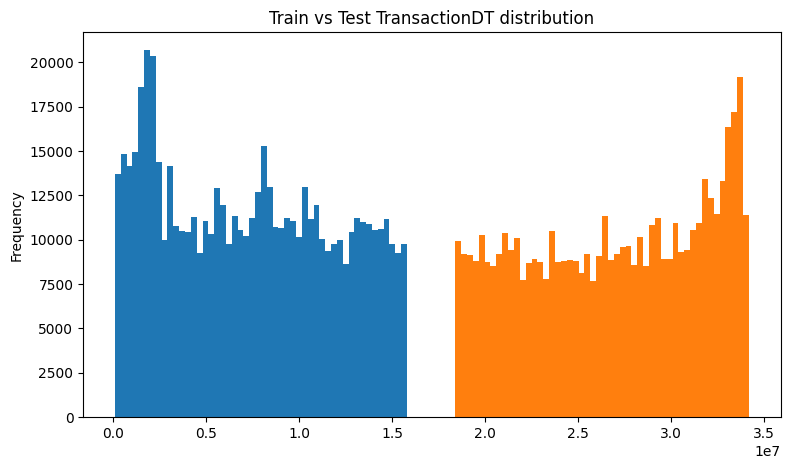

In [28]:
plt.figure(figsize=(9,5))
color_pal = [x['color'] for x in plt.rcParams['axes.prop_cycle']]
plt.title('Train vs Test TransactionDT distribution')
train['TransactionDT'].plot(kind='hist',label='train',bins=50)
test['TransactionDT'].plot(kind='hist',label='test',bins=50, color=color_pal[1])
plt.show()

Obs: Os dados de treinamento e teste parecem ser divididos por tempo. Há um pequeno intervalo entre eles, mas, caso contrário, o conjunto de treinamento é de um período anterior e o teste é de um período posterior. Isso afetará quais técnicas de validação cruzada devem ser usadas.

In [29]:
START_DATE = '2017-12-01'
startdate = datetime.datetime.strptime(START_DATE, '%Y-%m-%d')
train['TransactionDT'] = train['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds = x)))
test['TransactionDT'] = test['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds = x)))

train['year'] = train['TransactionDT'].dt.year
train['month'] = train['TransactionDT'].dt.month
train['dow'] = train['TransactionDT'].dt.dayofweek
train['hour'] = train['TransactionDT'].dt.hour
train['day'] = train['TransactionDT'].dt.day

test['year'] = test['TransactionDT'].dt.year
test['month'] = test['TransactionDT'].dt.month
test['dow'] = test['TransactionDT'].dt.dayofweek
test['hour'] = test['TransactionDT'].dt.hour
test['day'] = test['TransactionDT'].dt.day

In [30]:
# Parte 1 -> Count Transaction 	Percent Transaction Percent Fraud

tmp = pd.crosstab(train['hour'], train['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

percent_transact = round(train['hour'].value_counts(normalize=True) * 100, 2)
df = pd.concat([tmp, percent_transact], axis=1)
df.drop('NoFraud', axis=1, inplace=True)
df.rename(columns={'Fraud':'Percent Fraud', 'proportion':'Percent Transaction'}, inplace=True)

count_transaction = pd.DataFrame(train.groupby('hour')['TransactionID'].count())
df = df.merge(count_transaction, how='inner', on='hour')
df.rename(columns={'TransactionID':'Count Transaction'}, inplace=True)

df = df[['hour', 'Count Transaction', 'Percent Transaction', 'Percent Fraud']]

# Parte 2 ->  Count TransactionAmt 	Percent TransactionAmt 	Percent Fraud TransactionAmt

total_amt = train.groupby(['isFraud'])['TransactionAmt'].sum().sum()

perc_amt = (train.groupby(['isFraud','hour'])['TransactionAmt'].sum() \
            / train.groupby(['hour'])['TransactionAmt'].sum() * 100).unstack('isFraud')
perc_amt = perc_amt.reset_index()
perc_amt.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
amt = train.groupby(['hour'])['TransactionAmt'].sum().reset_index()
perc_amt = perc_amt.fillna(0)

amt['per'] = amt['TransactionAmt'] / total_amt*100
amt['per'] = round(amt['per'], 2)

df = df.merge(amt, how='inner', on='hour')
df.rename(columns={'TransactionAmt':'Count TransactionAmt', 'per':'Percent TransactionAmt'}, inplace=True)

percent_fraud_transactionAmt = round(pd.crosstab(index=train['hour'], columns=train['isFraud'], values=train['TransactionAmt'], aggfunc='sum', normalize='index') * 100, 2)
df = df.merge(percent_fraud_transactionAmt, how='inner', on='hour')
df.drop(0, axis=1, inplace=True)
df.rename(columns={1:'Percent Fraud TransactionAmt'}, inplace=True)

In [31]:
df

,hour,Count Transaction,Percent Transaction,Percent Fraud,Count TransactionAmt,Percent TransactionAmt,Percent Fraud TransactionAmt
0,0,37795,6.40,3.137981,4660496.261,5.84,3.59
1,1,32797,5.55,3.131384,3805384.966,4.77,3.67
2,2,26732,4.53,3.748317,2976132.281,3.73,4.13
3,3,20802,3.52,3.831362,2217529.208,2.78,4.21
4,4,14839,2.51,5.189029,1527838.580,1.92,5.44
5,5,9701,1.64,7.030203,1021159.892,1.28,7.75
6,6,6007,1.02,7.774263,635052.612,0.80,7.98
7,7,3704,0.63,10.610151,421726.359,0.53,9.36
8,8,2591,0.44,9.301428,325013.260,0.41,11.95
9,9,2479,0.42,8.995563,358256.811,0.45,13.52


#### Analisando Hour

In [32]:
def ploting_cnt_amt(df, col, lim=2000):
    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    
    plt.figure(figsize=(16,14))    
    plt.suptitle(f'{col} Distributions ', fontsize=24)
    
    plt.subplot(211)
    g = sns.countplot( x=col,  data=df, order=list(tmp[col].values))
    gt = g.twinx()
    gt = sns.pointplot(x=col, y='Fraud', data=tmp, order=list(tmp[col].values),
                       color='black')
    gt.set_ylim(0,tmp['Fraud'].max()*1.1)
    gt.set_ylabel("%Fraud Transactions", fontsize=16)
    g.set_title(f"Most Frequent {col} values and % Fraud Transactions", fontsize=20)
    g.set_xlabel(f"{col} ", fontsize=16)
    g.set_ylabel("Count", fontsize=17)
    g.set_xticklabels(g.get_xticklabels(),rotation=45)
    sizes = []
    for p in g.patches:
        height = p.get_height()
        sizes.append(height)
        g.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total*100),
                ha="center",fontsize=12) 
        
    g.set_ylim(0,max(sizes)*1.15)
    
    #########################################################################
    perc_amt = (df.groupby(['isFraud',col])['TransactionAmt'].sum() \
                / df.groupby([col])['TransactionAmt'].sum() * 100).unstack('isFraud')
    perc_amt = perc_amt.reset_index()
    perc_amt.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    amt = df.groupby([col])['TransactionAmt'].sum().reset_index()
    perc_amt = perc_amt.fillna(0)
    plt.subplot(212)
    g1 = sns.barplot(x=col, y='TransactionAmt', 
                       data=amt, 
                       order=list(tmp[col].values))
    g1t = g1.twinx()
    g1t = sns.pointplot(x=col, y='Fraud', data=perc_amt, 
                        order=list(tmp[col].values),
                       color='black')
    g1t.set_ylim(0,perc_amt['Fraud'].max()*1.1)
    g1t.set_ylabel("%Fraud Total Amount", fontsize=16)
    g.set_xticklabels(g.get_xticklabels(),rotation=45)
    g1.set_title(f"{col} by Transactions Total + %of total and %Fraud Transactions", fontsize=20)
    g1.set_xlabel(f"{col} ", fontsize=16)
    g1.set_ylabel("Transaction Total Amount(U$)", fontsize=16)
    g1.set_xticklabels(g.get_xticklabels(),rotation=45)    
    
    for p in g1.patches:
        height = p.get_height()
        g1.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total_amt*100),
                ha="center",fontsize=12) 
        
    plt.subplots_adjust(hspace=.4, top = 0.9)
    plt.show()

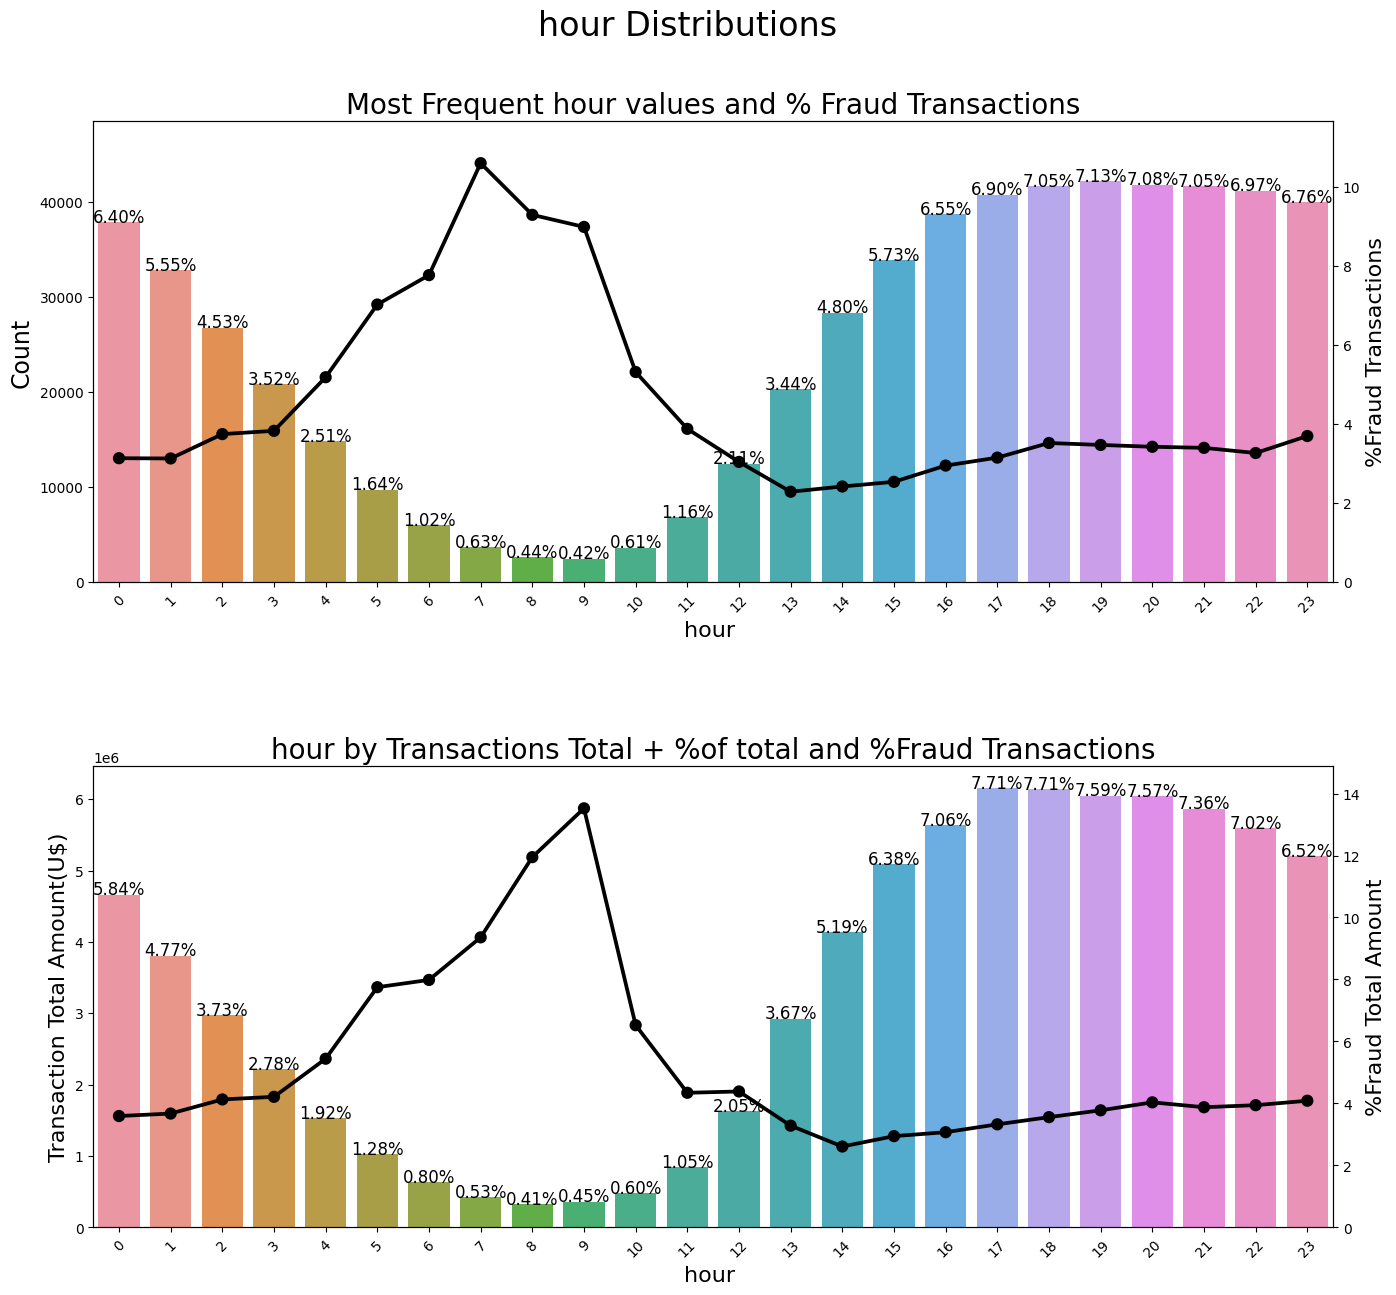

In [33]:
ploting_cnt_amt(train, 'hour')

**Grafico 1**<br>
- Os pontos pretos indicam a porcentagem de transações fraudulentas p/ hora.
- As porcentagens em cima das barras indicam a quantidade de transações por hora em porcentagem do total.<br>

**Grafico 2**<br>
- Os pontos pretos indicam a quantidade do valor por transação fraudulenta p/ hora.
- As porcentagens em cima das barras indicam a quantidade do valor por transação em porcentagem do total.

INSIGHT

ESCREVER AQUI

#### Analisando Day

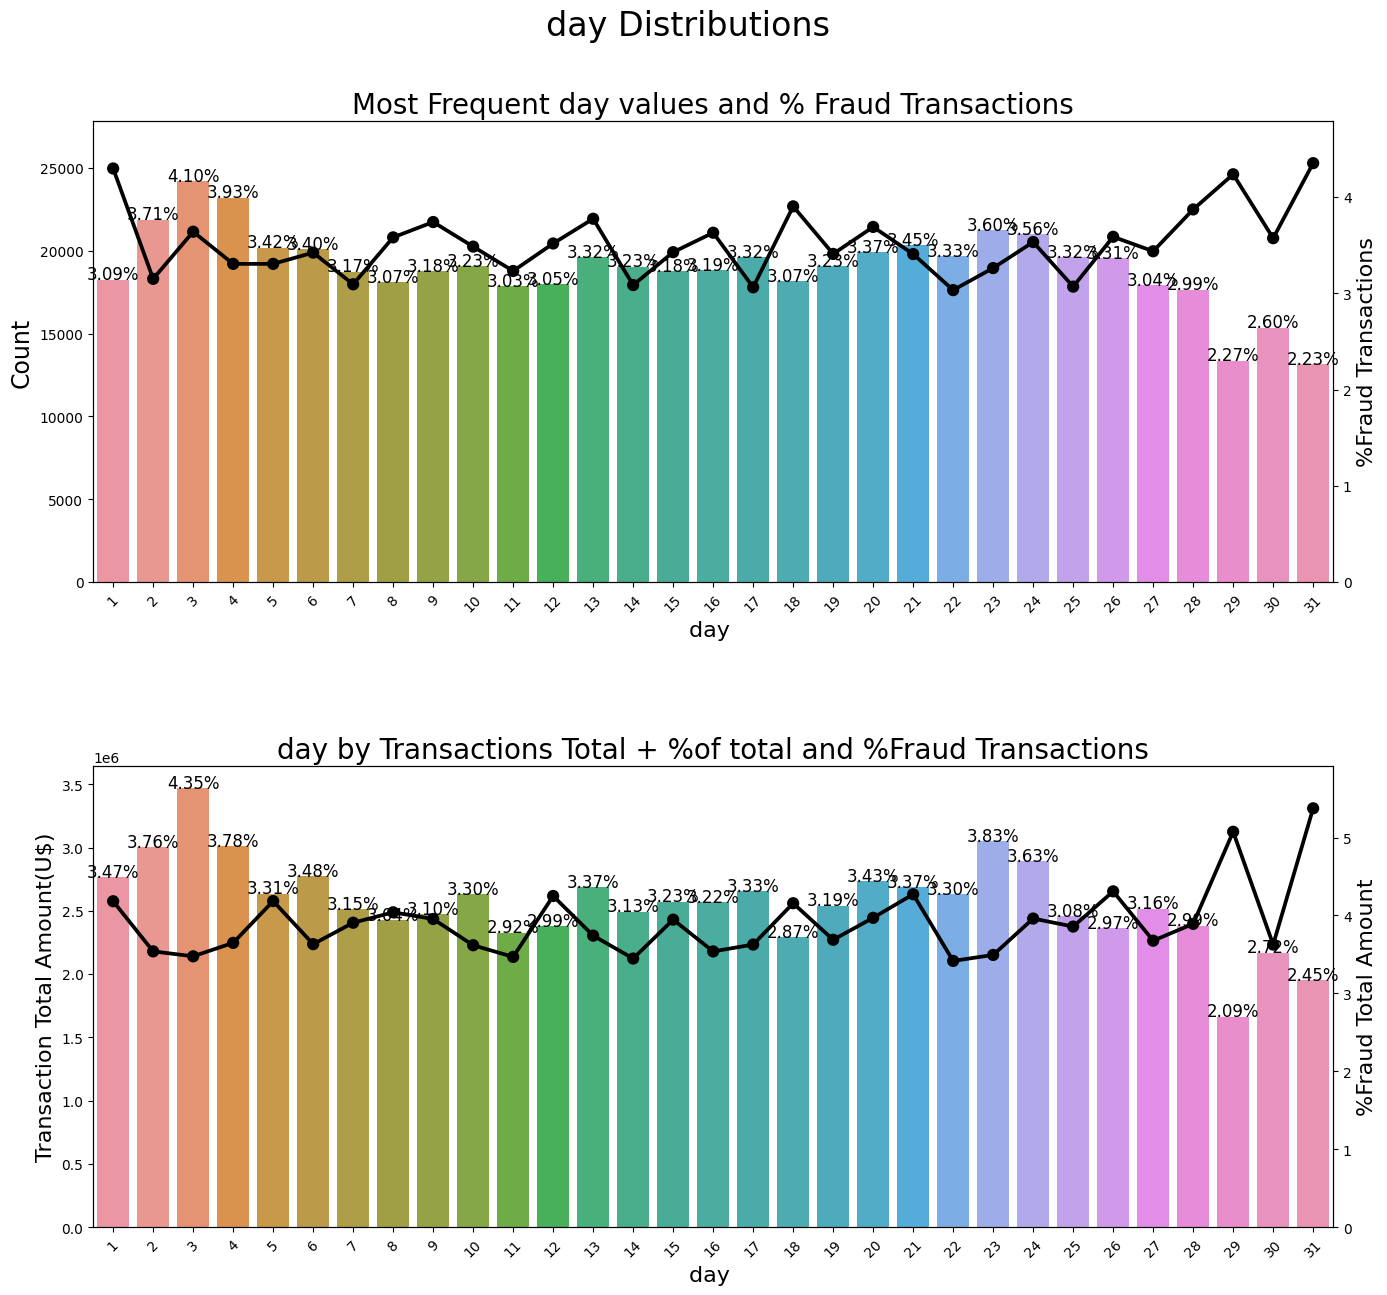

In [34]:
ploting_cnt_amt(train, 'day')

INSIGHT 

ESCREVER AQUI

### Variável TransactionAmt

#### Média dos valores por Transações (Normal/Fraud)

In [35]:
print(pd.concat([train[train['isFraud'] == 0]['TransactionAmt'].describe().reset_index(),
          train[train['isFraud'] == 1]['TransactionAmt'].describe().reset_index()],
          axis=1, keys=['No Fraud', "Fraud"]))

#print(pd.concat([train[train['isFraud'] == 1]['TransactionAmt'].quantile([.01, .1, .25, .5, .75, .9, .99]).reset_index(), 
#                 train[train['isFraud'] == 0]['TransactionAmt'].quantile([.01, .1, .25, .5, .75, .9, .99]).reset_index()],
##                 axis=1, keys=['Fraud', "No Fraud"]))

  No Fraud                 Fraud               
     index TransactionAmt  index TransactionAmt
0    count  569877.000000  count   20663.000000
1     mean     134.511665   mean     149.244779
2      std     239.395078    std     232.212163
3      min       0.251000    min       0.292000
4      25%      43.970000    25%      35.044000
5      50%      68.500000    50%      75.000000
6      75%     120.000000    75%     161.000000
7      max   31937.391000    max    5191.000000


#### Distribuição dos Valores

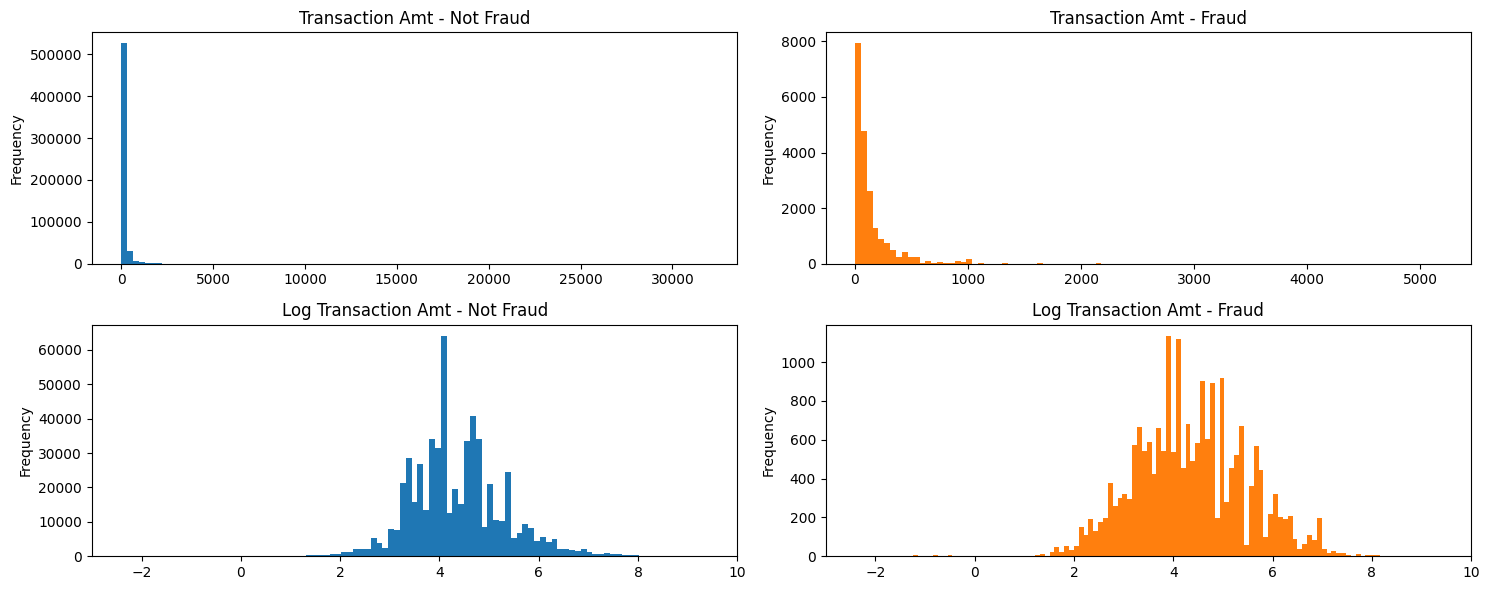

In [36]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 6))

train[train['isFraud'] == 0]['TransactionAmt'].plot(kind='hist',bins=100,title='Transaction Amt - Not Fraud',ax=ax1)
train[train['isFraud'] == 1]['TransactionAmt'].plot(kind='hist',bins=100,title='Transaction Amt - Fraud',color=color_pal[1],ax= ax2)
train[train['isFraud'] == 0]['TransactionAmt'].apply(np.log).plot(kind='hist',bins=100,title='Log Transaction Amt - Not Fraud',xlim=(-3, 10),ax=ax3)
train[train['isFraud'] == 1]['TransactionAmt'].apply(np.log).plot(kind='hist',bins=100,title='Log Transaction Amt - Fraud',color=color_pal[1],xlim=(-3, 10),ax= ax4)
plt.tight_layout()
plt.show()

INSIGHT

ESCREVER AQUI

### Variáveis Categóricas

In [37]:
cat_vars = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'P_emaildomain']
train[cat_vars].head()

,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain
0,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf
1,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google
2,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft
3,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo
4,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google


#### Variável ProductCD

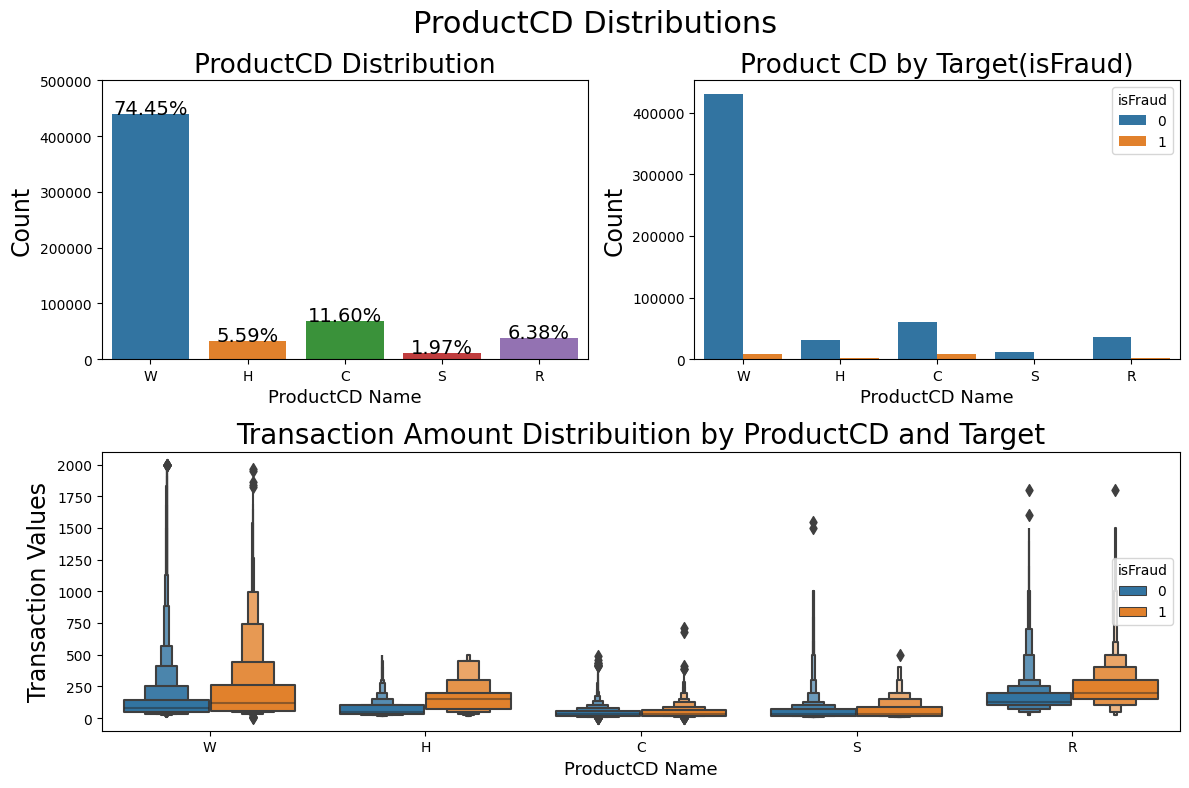

In [38]:
plt.figure(figsize=(12,8))
plt.suptitle('ProductCD Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='ProductCD', data=train)
g.set_title("ProductCD Distribution", fontsize=19)
g.set_xlabel("ProductCD Name", fontsize=13)
g.set_ylabel("Count", fontsize=17)
g.set_ylim(0,500000)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=14) 

plt.subplot(222)
g1 = sns.countplot(x='ProductCD', hue='isFraud', data=train)
g1.set_title("Product CD by Target(isFraud)", fontsize=19)
g1.set_xlabel("ProductCD Name", fontsize=13)
g1.set_ylabel("Count", fontsize=17)
plt.subplot(212)

g3 = sns.boxenplot(x='ProductCD', y='TransactionAmt', hue='isFraud', data=train[train['TransactionAmt'] <= 2000] )
g3.set_title("Transaction Amount Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("ProductCD Name", fontsize=13)
g3.set_ylabel("Transaction Values", fontsize=17)
plt.tight_layout()
plt.show()

INSIGHT

ESCREVER AQUI

#### Numericals Feature Card

In [39]:
train[['card1', 'card2', 'card3', 'card4', 'card5', 'card6']].head()

,card1,card2,card3,card4,card5,card6
0,13926,361.0,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


In [40]:
print("Card Features Quantiles: ")
print(train[['card1', 'card2', 'card3', 'card5']].quantile([0.01, .025, .1, .25, .5, .75, .975, .99]))

Card Features Quantiles: 
         card1  card2  card3  card5
0.010   1338.0  100.0  144.0  102.0
0.025   1675.0  111.0  150.0  102.0
0.100   2803.0  113.0  150.0  126.0
0.250   6019.0  215.0  150.0  166.0
0.500   9678.0  361.0  150.0  226.0
0.750  14184.0  512.0  150.0  226.0
0.975  18018.0  583.0  185.0  226.0
0.990  18238.0  583.0  185.0  226.0


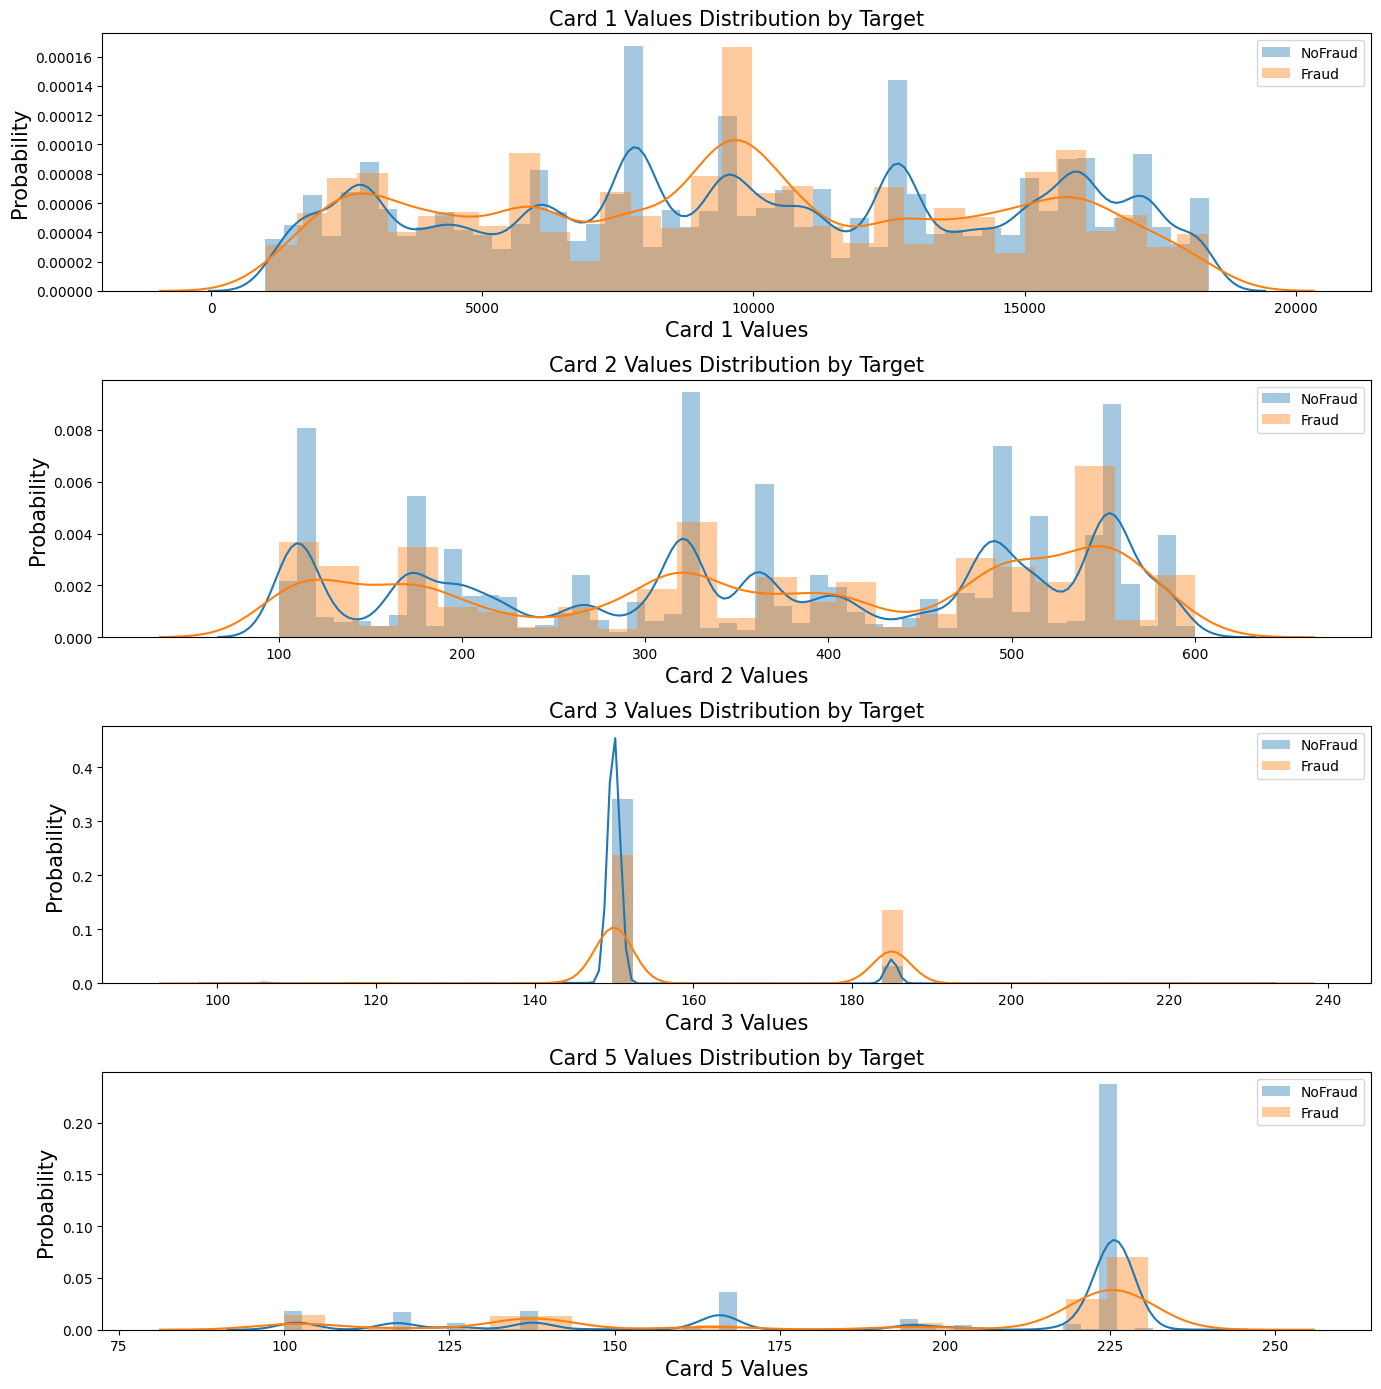

In [41]:
plt.figure(figsize=(14,14))

plt.subplot(411)
g = sns.distplot(train[train['isFraud'] == 0]['card1'], label='NoFraud')
g = sns.distplot(train[train['isFraud'] == 1]['card1'], label='Fraud')
g.legend()
g.set_title("Card 1 Values Distribution by Target", fontsize=15)
g.set_xlabel("Card 1 Values", fontsize=15)
g.set_ylabel("Probability", fontsize=15)

plt.subplot(412)
g = sns.distplot(train[train['isFraud'] == 0]['card2'], label='NoFraud')
g = sns.distplot(train[train['isFraud'] == 1]['card2'], label='Fraud')
g.legend()
g.set_title("Card 2 Values Distribution by Target", fontsize=15)
g.set_xlabel("Card 2 Values", fontsize=15)
g.set_ylabel("Probability", fontsize=15)

plt.subplot(413)
g = sns.distplot(train[train['isFraud'] == 0]['card3'], label='NoFraud')
g = sns.distplot(train[train['isFraud'] == 1]['card3'], label='Fraud')
g.legend()
g.set_title("Card 3 Values Distribution by Target", fontsize=15)
g.set_xlabel("Card 3 Values", fontsize=15)
g.set_ylabel("Probability", fontsize=15)

plt.subplot(414)
g = sns.distplot(train[train['isFraud'] == 0]['card5'], label='NoFraud')
g = sns.distplot(train[train['isFraud'] == 1]['card5'], label='Fraud')
g.legend()
g.set_title("Card 5 Values Distribution by Target", fontsize=15)
g.set_xlabel("Card 5 Values", fontsize=15)
g.set_ylabel("Probability", fontsize=15)

plt.tight_layout()
plt.show()

INSIGHT

ESCREVER ALGO

In [42]:
print(pd.concat([train[train['isFraud'] == 0]['card3'].describe().reset_index(),
          train[train['isFraud'] == 1]['card3'].describe().reset_index()],
          axis=1, keys=['No Fraud', "Fraud"]))

  No Fraud                 Fraud              
     index          card3  index         card3
0    count  569877.000000  count  20663.000000
1     mean     152.854370   mean    162.345303
2      std      10.890827    std     17.487497
3      min     100.000000    min    100.000000
4      25%     150.000000    25%    150.000000
5      50%     150.000000    50%    150.000000
6      75%     150.000000    75%    185.000000
7      max     231.000000    max    231.000000


#### Categorical Features Card

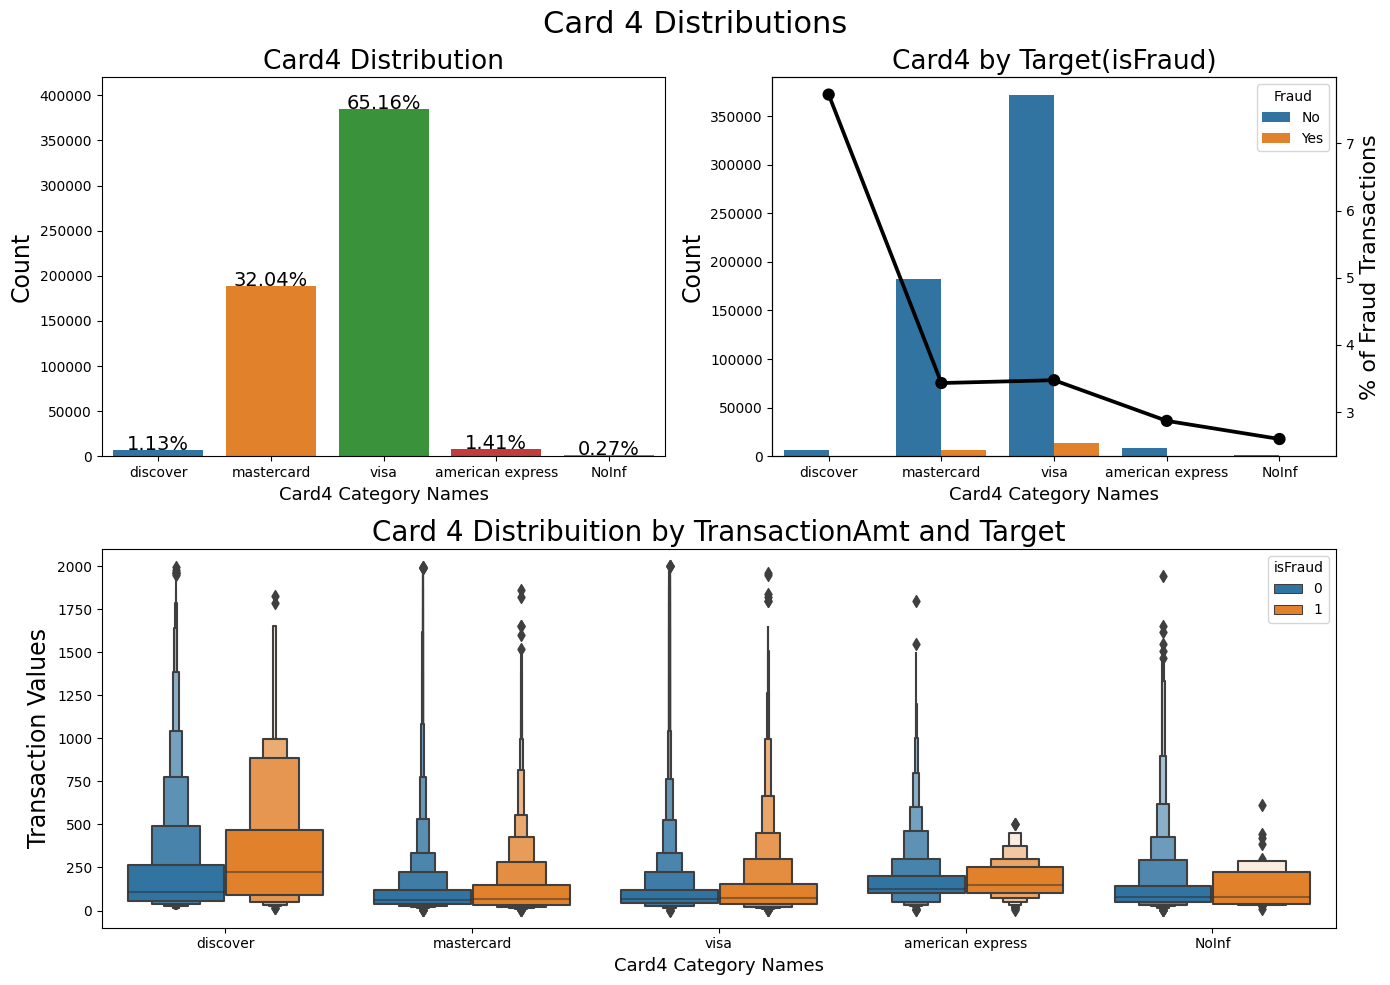

In [43]:
tmp = pd.crosstab(train['card4'], train['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 4 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card4', data=train)
# plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])
g.set_title("Card4 Distribution", fontsize=19)
g.set_ylim(0,420000)
g.set_xlabel("Card4 Category Names", fontsize=13)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14) 

plt.subplot(222)
g1 = sns.countplot(x='card4', hue='isFraud', data=train)
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card4', y='Fraud', data=tmp, color='black', order=['discover', 'mastercard', 'visa', 'american express', 'NoInf'])
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card4 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card4 Category Names", fontsize=13)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card4', y='TransactionAmt', hue='isFraud', 
              data=train[train['TransactionAmt'] <= 2000] )
g3.set_title("Card 4 Distribuition by TransactionAmt and Target", fontsize=20)
g3.set_xlabel("Card4 Category Names", fontsize=13)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.tight_layout()
plt.show()

INSIGHT

ESCREVER AQUI

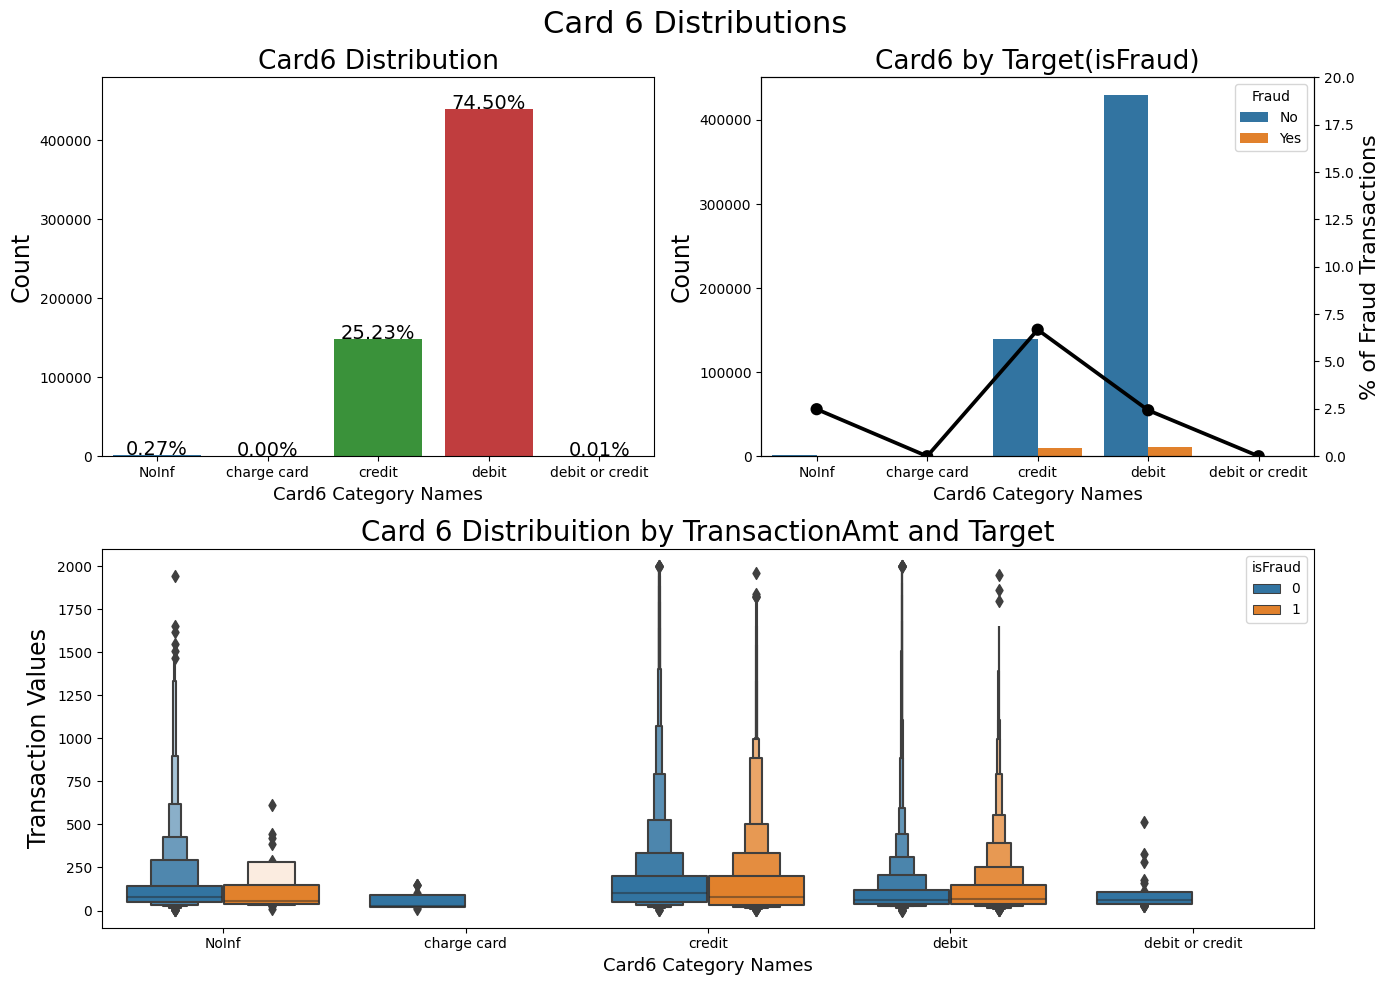

In [44]:
tmp = pd.crosstab(train['card6'], train['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 6 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card6', data=train, order=list(tmp.card6.values))
# plt.legend(title='Fraud', loc='upper center', labels=['No', 'Yes'])
g.set_title("Card6 Distribution", fontsize=19)
g.set_ylim(0,480000)
g.set_xlabel("Card6 Category Names", fontsize=13)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14) 

plt.subplot(222)
g1 = sns.countplot(x='card6', hue='isFraud', data=train, order=list(tmp.card6.values))
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card6', y='Fraud', data=tmp, order=list(tmp.card6.values), color='black')
gt.set_ylim(0,20)
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card6 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card6 Category Names", fontsize=13)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card6', y='TransactionAmt', hue='isFraud', order=list(tmp.card6.values), data=train[train['TransactionAmt'] <= 2000] )
g3.set_title("Card 6 Distribuition by TransactionAmt and Target", fontsize=20)
g3.set_xlabel("Card6 Category Names", fontsize=13)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)
plt.tight_layout()
plt.show()

INSIGHT

ESCREVER AQUI

#### Ploting P-Email Domain

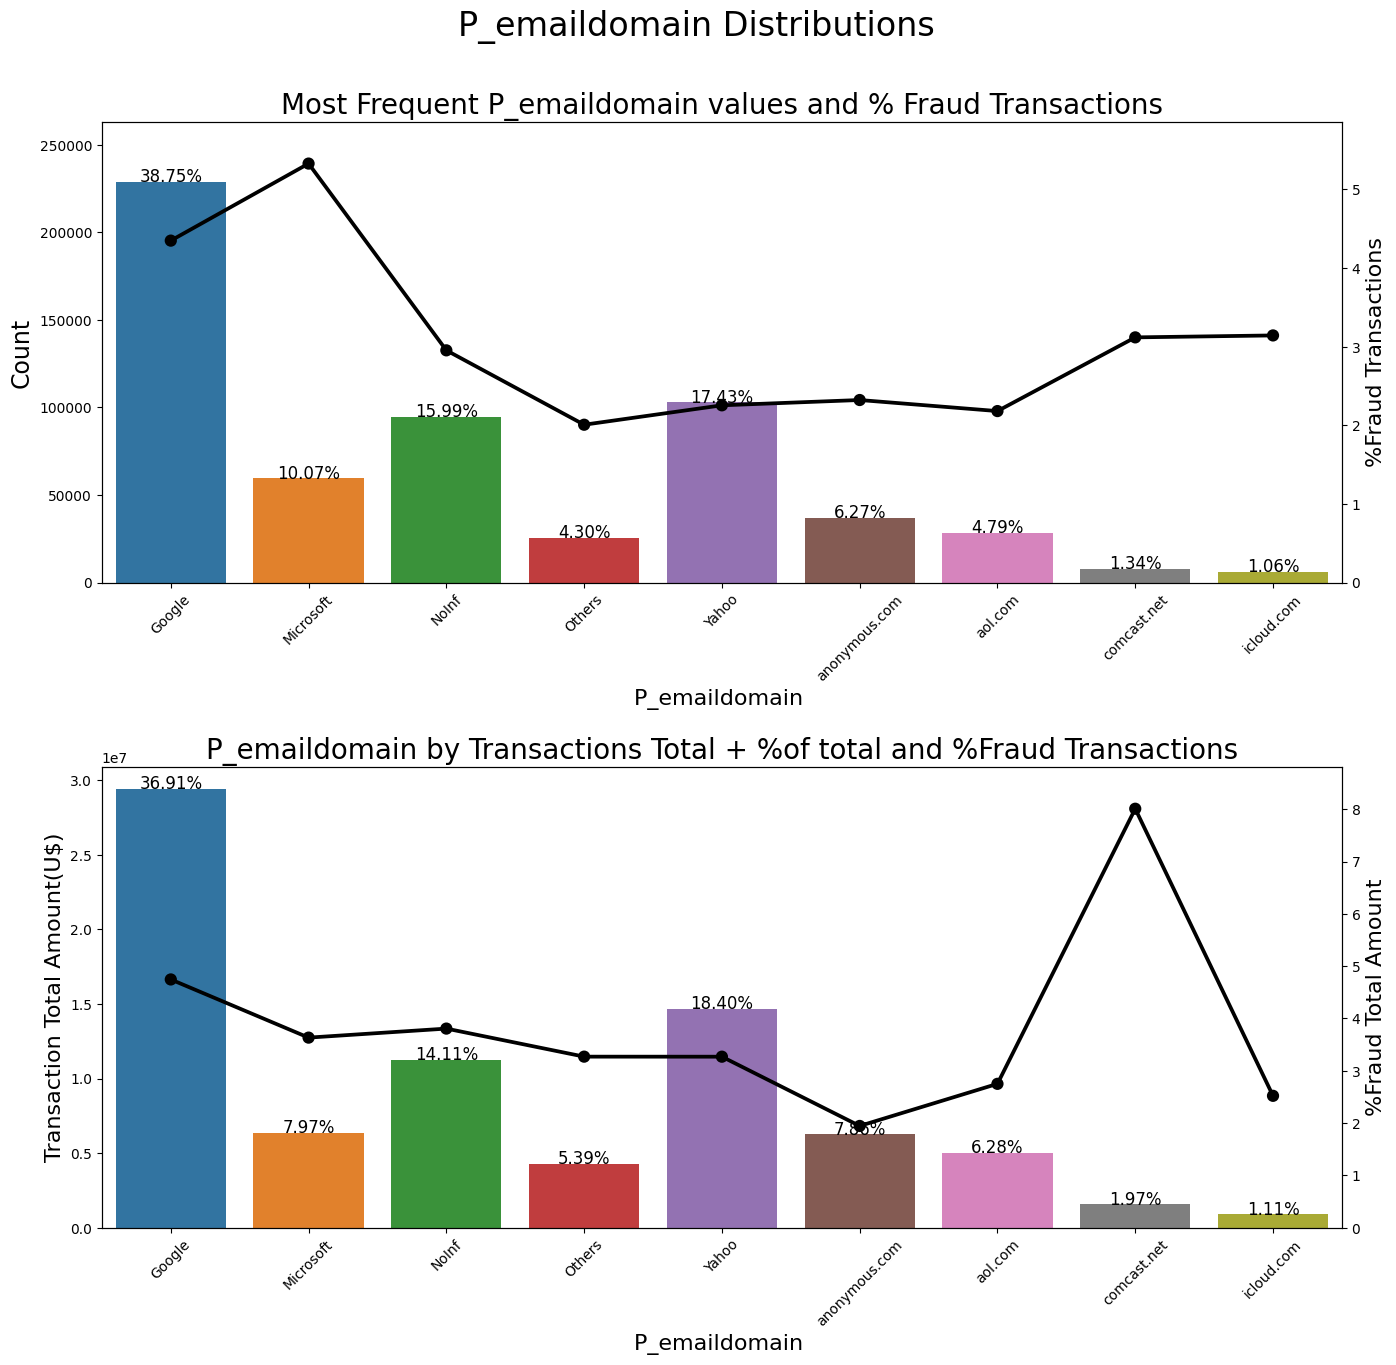

In [45]:
ploting_cnt_amt(train, 'P_emaildomain')

INSIGHT 

HERE

### Variáveis Numéricas

In [46]:
train.iloc[:,13:].describe()

,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,year,month,dow,hour,day
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.00000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.00000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215,94.153422,106.534282,109.695071,146.580423,0.616429,0.650801,0.106582,0.107556,0.116773,0.117926,0.840026,0.867443,0.112978,0.115250,0.337879,0.354079,0.122628,0.124071,0.113857,0.121228,0.673470,0.699600,1.077145,1.115933,0.118558,0.126459,0.111449,0.120603,1.086221,0.273538,0.283925,0.117608,0.121772,0.130421,0.632733,0.669594,1.105185,0.111561,0.115161,0.116883,0.123929,0.852007,0.884853,0.113674,0.123309,0.339259,0.354669,0.122278,0.126178,0.121707,0.132284,0.613086,0.649831,1.073773,1.12265,0.116202,0.122219,0.129641,0.868072,0.899787,0.116437,0.127172,1.084440,0.341186,0.356977,0.127626,0.131437,0.116321,1.037467,3.003592,1.718019,0.061952,0.894510,0.273358,0.888776,1.826257,1.278608,0.280995,0.164497,1.092925,129.910305,336.432577,203.985518,8.764282,92.116843,31.116748,103.458149,204.780217,145.894712,38.800554,26.351071,1.123038,1.967042,0.817564,0.991134,0.088541,1.167636,0.358572,0.183954,0.235468,1.103009,1.659798,1.239911,0.942580,2.313816,1.433395,0.32821,0.089032,0.298823,0.171651,0.251756,0.283134,0.264202,139.745873,408.674070,230.408498,10.995763,118.193256,39.173114,21.305592,43.226087,26.749372,109.816313,247.601710,162.150103,18.372102,42.072278,28.3260

#### C Columns

Because we are provided many numerical columns, we can create a pairplot to plot feature interactions. I know these plots can be hard to read, but it is helpful for gaining intution about potential feature interactions and if certain features have more variance than others.

In [47]:
c_cols = [c for c in train if c[0] == 'C']
train[c_cols].head()

,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
3,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0
4,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0


In [48]:
train[c_cols].describe()

,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


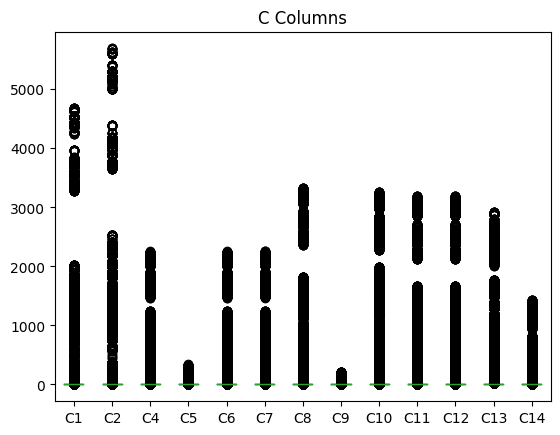

In [49]:
train[c_cols].plot.box()
plt.title('C Columns')
plt.show()

In [50]:
sel_c_cols = ['C1', 'C5', 'C7', 'C9', 'C11', 'C13']

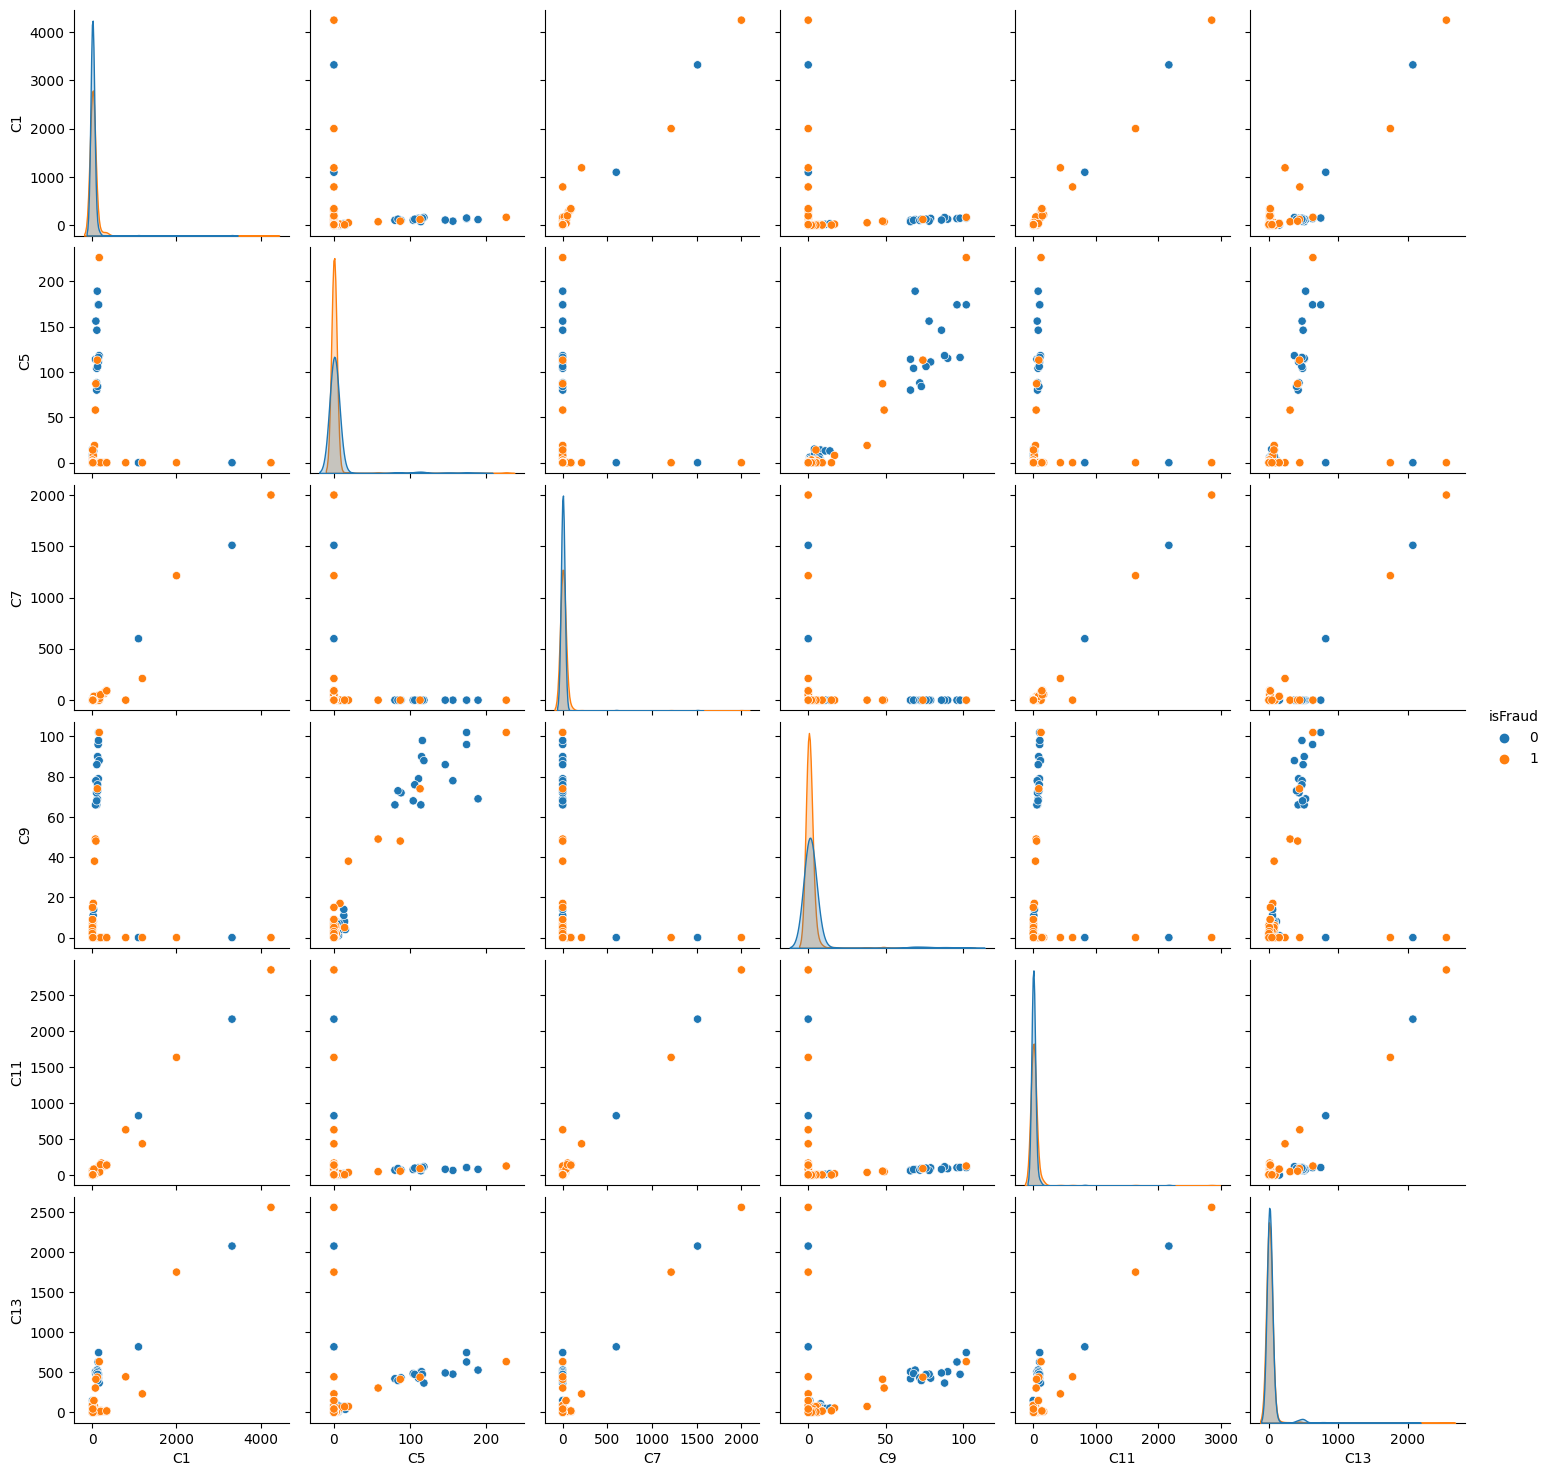

In [51]:
sampled_train = pd.concat([train.loc[train['isFraud'] == 0].sample(500),
          train[train['isFraud'] == 1].sample(500)])

sns.pairplot(sampled_train, 
             hue='isFraud',
            vars=sel_c_cols)
plt.show()

#### D Columns

In [52]:
d_cols = [c for c in train if c[0] == 'D']
train[d_cols].head()

,D1,D4,D10,D15
0,14.0,23.0,13.0,0.0
1,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,315.0
3,112.0,94.0,84.0,111.0
4,0.0,23.0,13.0,50.0


In [53]:
train[d_cols].describe()

,D1,D4,D10,D15
count,590540.000000,590540.000000,590540.000000,590540.000000
mean,94.153422,106.534282,109.695071,146.580423
std,157.546457,169.905435,174.461383,191.191196
min,0.000000,-122.000000,0.000000,-83.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,3.000000,23.000000,13.000000,50.000000
75%,121.000000,123.000000,150.000000,251.000000
max,640.000000,869.000000,876.000000,879.000000


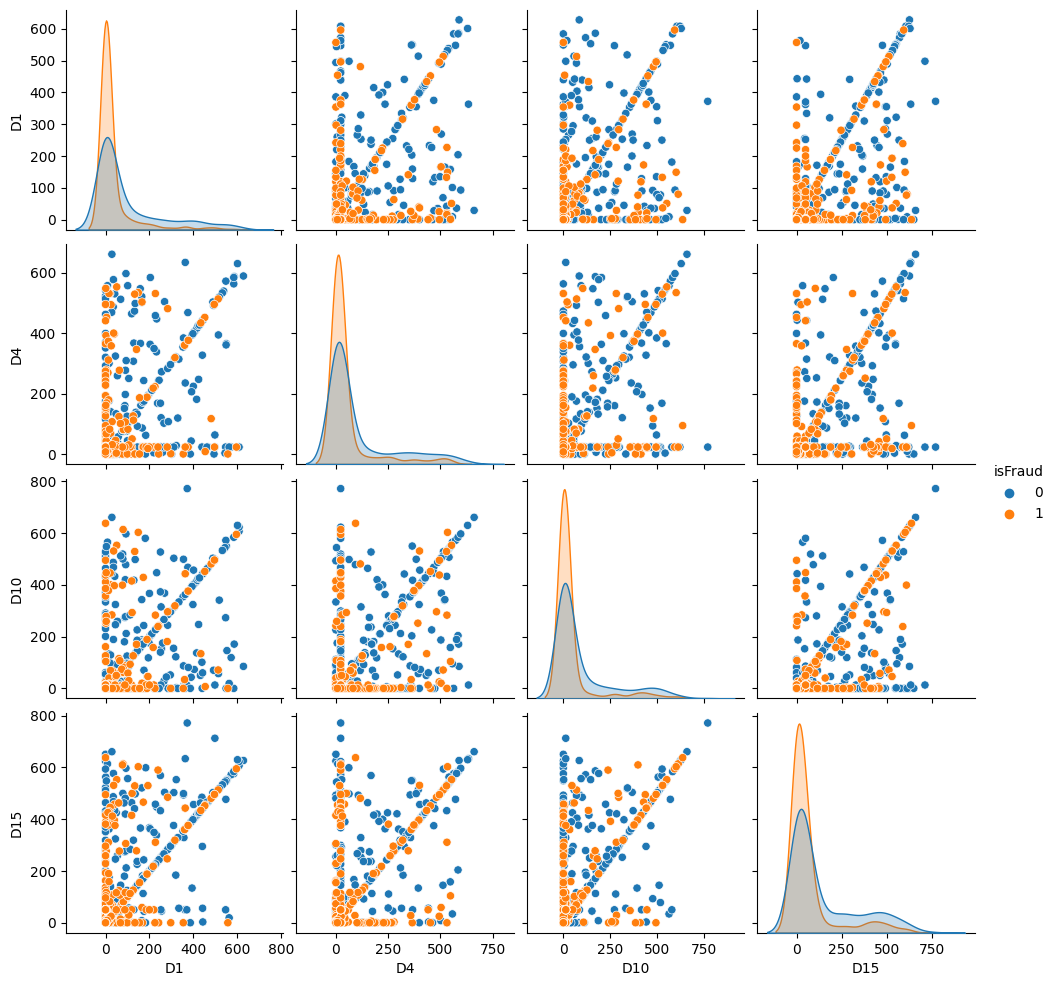

In [54]:
sampled_train = pd.concat([train.loc[train['isFraud'] == 0].sample(500),
          train[train['isFraud'] == 1].sample(500)])

sns.pairplot(sampled_train, 
             hue='isFraud',
            vars=d_cols)
plt.show()

#### V Columns

In [55]:
v_cols = [c for c in train if c[0] == 'V']
train[v_cols].head()

,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,0.0,10.0,4.0,1.0,38.0,24.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,135.0,50.0,1404.0,790.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,1758.0,925.0,0.0,354.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
train[v_cols].describe()

,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.00000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.00000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,0.616429,0.650801,0.106582,0.107556,0.116773,0.117926,0.840026,0.867443,0.112978,0.115250,0.337879,0.354079,0.122628,0.124071,0.113857,0.121228,0.673470,0.699600,1.077145,1.115933,0.118558,0.126459,0.111449,0.120603,1.086221,0.273538,0.283925,0.117608,0.121772,0.130421,0.632733,0.669594,1.105185,0.111561,0.115161,0.116883,0.123929,0.852007,0.884853,0.113674,0.123309,0.339259,0.354669,0.122278,0.126178,0.121707,0.132284,0.613086,0.649831,1.073773,1.12265,0.116202,0.122219,0.129641,0.868072,0.899787,0.116437,0.127172,1.084440,0.341186,0.356977,0.127626,0.131437,0.116321,1.037467,3.003592,1.718019,0.061952,0.894510,0.273358,0.888776,1.826257,1.278608,0.280995,0.164497,1.092925,129.910305,336.432577,203.985518,8.764282,92.116843,31.116748,103.458149,204.780217,145.894712,38.800554,26.351071,1.123038,1.967042,0.817564,0.991134,0.088541,1.167636,0.358572,0.183954,0.235468,1.103009,1.659798,1.239911,0.942580,2.313816,1.433395,0.32821,0.089032,0.298823,0.171651,0.251756,0.283134,0.264202,139.745873,408.674070,230.408498,10.995763,118.193256,39.173114,21.305592,43.226087,26.749372,109.816313,247.601710,162.150103,18.372102,42.072278,28.326009
std,0.498822,0.514556,0.312968,0.322659,0.343124,0.349943,0.401896,0.431856,0.319436,0.338382,0.494019,0.534993,0.335418,0.347035,0.321184,0.336966,0.482509,0.493552,0.585511,0.729412,0.389169,0.434779,0.331118,0.374026,0.619005,0.462981,0.492470,0.324646,0.349858,0.379996,0.497787,0.514694,0.617810,0.328368,0.350566,0.356555,0.392920,0.411139,0.453320,0.334177,0.381720,0.496704,0.534992,0.342980,0.366196,0.345531,0.370271,0.501204,0.517454,0.492062,0.72192,0.353464,0.381219,0.420326,0.393281,0.435818,0.337034,0.390188,0.472448,0.496881,0.539156

In [57]:
# Feature Engineering

train['v_mean'] = train[v_cols].mean(axis=1)
test['v_mean'] = test[v_cols].mean(axis=1)

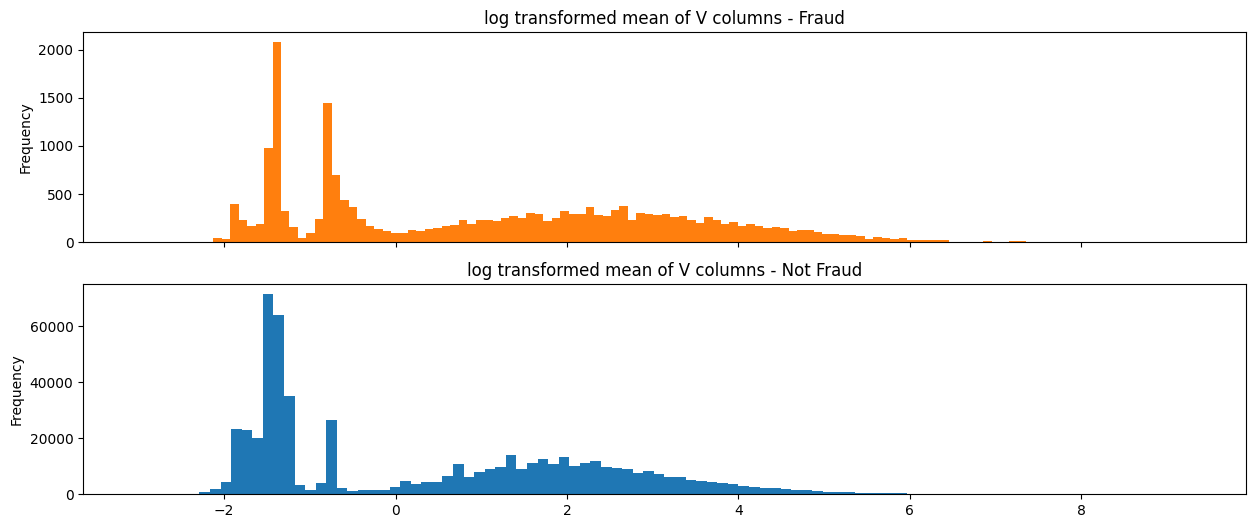

In [58]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(15, 6))
train[train['isFraud'] == 1]['v_mean'].apply(np.log).plot(kind='hist',bins=100,title='log transformed mean of V columns - Fraud',color=color_pal[1], ax=ax1)
train[train['isFraud'] == 0]['v_mean'].apply(np.log).plot(kind='hist',bins=100,title='log transformed mean of V columns - Not Fraud',ax=ax2)
plt.show()

In [59]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,year,month,dow,hour,day,v_mean
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,2017,12,5,0,2,4.000000
1,2987001,0,2017-12-02 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,12,5,0,2,0.153226
2,2987002,0,2017-12-02 00:01:09,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,12,5,0,2,0.217742
3,2987003,0,2017-12-02 00:01:39,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,0.0,10.0,4.0,1.0,38.0,24.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,135.0,50.0,1404.0,790.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,1758.0,925.0,0.0,354.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,2017,12,5,0,2,90.459677
4,2987004,0,2017-12-02 00:01:46,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0

In [51]:
train['cents'] = (train['TransactionAmt'] - np.floor(train['TransactionAmt'])).astype('float32')
test['cents'] = (test['TransactionAmt'] - np.floor(test['TransactionAmt'])).astype('float32')

In [52]:
# LABEL ENCODE
def encode_LE(col,train=train,test=test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')

# COMBINE FEATURES
def encode_CB(col1,col2,df1=train,df2=test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')

card1_addr1 , card1_addr1_P_emaildomain , 

In [53]:
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=train, test_df=test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')

encode_AG(['TransactionAmt'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 

In [ ]:
# New feature - log of transaction amount.
#train['TransactionAmt_Log'] = np.log(train['TransactionAmt'])
#test['TransactionAmt_Log'] = np.log(test['TransactionAmt'])

In [ ]:
#train['v_mean'] = np.log(train['v_mean'])
#test['v_mean'] = np.log(test['v_mean'])

In [63]:
print(train.shape, test.shape)
display(train.head())
display(test.head())

(590540, 159) (506691, 158)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,year,month,dow,hour,day
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,2017,12,5,0,2
1,2987001,0,2017-12-02 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,12,5,0,2
2,2987002,0,2017-12-02 00:01:09,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,12,5,0,2
3,2987003,0,2017-12-02 00:01:39,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,0.0,10.0,4.0,1.0,38.0,24.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,135.0,50.0,1404.0,790.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,1758.0,925.0,0.0,354.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,2017,12,5,0,2
4,2987004,0,2017-12-02 00:01:46,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,year,month,dow,hour,day
0,3663549,2018-07-02 00:00:24,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,Google,6.0,6.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,398.0,418.0,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2018,7,0,0,2
1,3663550,2018-07-02 00:01:03,49.00,W,4272,111.0,150.0,visa,226.0,debit,299.0,aol.com,3.0,2.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,634.0,231.0,634.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,280.000000,77.000000,0.000000,280.000000,77.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,280.000000,77.000000,0.000000,280.000000,77.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2018,7,0,0,2
2,3663551,2018-07-02 00:01:50,171.00,W,4476,574.0,150.0,visa,226.0,debit,472.0,Microsoft,2.0,2.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,97.0,136.0,97.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.000000,968.000000,0.000000,0.000000,705.000000,0.000000,0.0,0.0,0.0,263.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.000000,1321.000000,0.000000,0.000000,1058.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,263.0,0.0,2018,7,0,0,2
3,3663552,2018-07-02 00:01:50,284.95,W,10989,360.0,150.0,visa,166.0,debit,205.0,Google,5.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,242.0,242.0,242.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,282.540009,282.540009,282.540009,0.0,0.0,0.0,0.0,0.0,0.0,2018,7,0,0,2
4,3663553,2018-07-02 00:01:57,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,264.0,Google,6.0,6.0,0.0,2.0,5.0,0.0,0.0,5.0,0.0,6.0,0.0,14.0,6.0,22.0,22.0,22.0,22.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0

In [61]:
test.drop('isFraud', axis=1, inplace=True)

In [64]:
train.to_csv('train_noFE.csv', index=False)
test.to_csv('test_noFE.csv', index=False)

## Loading Dataset

In [3]:
train = pd.read_csv('train_noFE.csv')
test = pd.read_csv('test_noFE.csv')
sub = pd.read_csv('dados/sample_submission.csv')

In [4]:
print(train.shape, test.shape)
display(train.head())
display(test.head())

(590540, 159) (506691, 158)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,year,month,dow,hour,day
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,361.0,150.0,discover,142.0,credit,315.0,NoInf,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,23.0,13.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,2017,12,5,0,2
1,2987001,0,2017-12-02 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,12,5,0,2
2,2987002,0,2017-12-02 00:01:09,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,Microsoft,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,315.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,12,5,0,2
3,2987003,0,2017-12-02 00:01:39,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,Yahoo,2.0,5.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,94.0,84.0,111.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,48.0,28.0,0.0,10.0,4.0,1.0,38.0,24.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,135.0,50.0,1404.0,790.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,10.0,4.0,0.0,0.0,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,1758.0,925.0,0.0,354.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,2017,12,5,0,2
4,2987004,0,2017-12-02 00:01:46,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,Google,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,23.0,13.0,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,C1,C2,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D4,D10,D15,V12,V13,V15,V16,V17,V18,V19,V20,V21,V22,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V42,V43,V45,V48,V49,V50,V51,V52,V53,V54,V56,V57,V58,V59,V60,V61,V62,V63,V64,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V87,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V105,V106,V124,V126,V127,V128,V129,V130,V131,V132,V133,V134,V136,V137,V279,V280,V282,V283,V284,V285,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V302,V303,V304,V306,V307,V308,V309,V310,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,year,month,dow,hour,day
0,3663549,2018-07-02 00:00:24,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,Google,6.0,6.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,398.0,418.0,409.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,47.950001,0.000000,0.000000,47.950001,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2018,7,0,0,2
1,3663550,2018-07-02 00:01:03,49.00,W,4272,111.0,150.0,visa,226.0,debit,299.0,aol.com,3.0,2.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,634.0,231.0,634.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,280.000000,77.000000,0.000000,280.000000,77.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,280.000000,77.000000,0.000000,280.000000,77.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2018,7,0,0,2
2,3663551,2018-07-02 00:01:50,171.00,W,4476,574.0,150.0,visa,226.0,debit,472.0,Microsoft,2.0,2.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,97.0,136.0,97.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.000000,968.000000,0.000000,0.000000,705.000000,0.000000,0.0,0.0,0.0,263.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.000000,1321.000000,0.000000,0.000000,1058.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,263.0,0.0,2018,7,0,0,2
3,3663552,2018-07-02 00:01:50,284.95,W,10989,360.0,150.0,visa,166.0,debit,205.0,Google,5.0,2.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,242.0,242.0,242.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,282.540009,282.540009,282.540009,0.0,0.0,0.0,0.0,0.0,0.0,2018,7,0,0,2
4,3663553,2018-07-02 00:01:57,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,264.0,Google,6.0,6.0,0.0,2.0,5.0,0.0,0.0,5.0,0.0,6.0,0.0,14.0,6.0,22.0,22.0,22.0,22.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0

In [8]:
# LABEL ENCODE AND MEMORY REDUCE
for i,f in enumerate(train.columns):
    # FACTORIZE CATEGORICAL VARIABLES
    if (np.str_(train[f].dtype)=='category')|(train[f].dtype=='object'): 
        df_comb = pd.concat([train[f],test[f]],axis=0)
        df_comb,_ = df_comb.factorize(sort=True)
        if df_comb.max()>32000: print(f,'needs int32')
        train[f] = df_comb[:len(train)].astype('int16')
        test[f] = df_comb[len(train):].astype('int16')
    # SHIFT ALL NUMERICS POSITIVE. SET NAN to -1
    elif f not in ['TransactionAmt','TransactionDT', 'isFraud']:
        mn = np.min((train[f].min(),test[f].min()))
        train[f] -= np.float32(mn)
        test[f] -= np.float32(mn)
        train[f].fillna(-1,inplace=True)
        test[f].fillna(-1,inplace=True)

TransactionDT needs int32


## Encoding categorical features

In [9]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')
        
# LABEL ENCODE
def encode_LE(col,train=train,test=test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')
        
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=train, test_df=test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')
                
# COMBINE FEATURES
def encode_CB(col1,col2,df1=train,df2=test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=train, test_df=test):
    for main_column in main_columns:  
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

In [57]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain']
train[cat_cols].describe()

,ProductCD,card4,card6,P_emaildomain
count,590540,590540,590540,590540
unique,5,5,5,9
top,W,visa,debit,Google
freq,439670,384767,439938,228851


### Dummy Variables

In [58]:
train = pd.get_dummies(train, drop_first=True, dtype=float)
test = pd.get_dummies(test, drop_first=True, dtype=float)

In [59]:
print("Variables in train but not in test: ", set(train.columns).difference(set(test.columns)))

In [59]:
train.drop('card6_debit or credit', axis=1, inplace=True)

Variables in train but not in test:  set()


### Label Encoding

In [67]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding
for f in train.drop('isFraud', axis=1).columns:
    if train[f].dtype=='object' or test[f].dtype=='object': 
        lbl = LabelEncoder()
        lbl.fit(list(train[f].values) + list(test[f].values))
        train[f] = lbl.transform(list(train[f].values))
        test[f] = lbl.transform(list(test[f].values))

## Feature Engineering

In [10]:
# TRANSACTION AMT CENTS
train['cents'] = (train['TransactionAmt'] - np.floor(train['TransactionAmt'])).astype('float32')
test['cents'] = (test['TransactionAmt'] - np.floor(test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(train,test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(train,test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

cents, addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , card1_addr1 , card1_addr1_P_emaildomain , card1_addr1_FE , card1_addr1_P_emaildomain_FE , 'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 

## Cross Validation

In [12]:
# Del year, month
train.drop(['year', 'month'], axis=1, inplace=True)
test.drop(['year', 'month'], axis=1, inplace=True)

In [13]:
#X = train.sort_values('TransactionDT').drop(['isFraud', 'TransactionDT', 'TransactionID'], axis=1)
#y = train.sort_values('TransactionDT')['isFraud']

X = train.drop(['isFraud', 'TransactionDT', 'TransactionID'], axis=1)
y = train['isFraud']

In [14]:
test.drop(['TransactionDT', 'TransactionID'], axis=1, inplace=True)
del train

In [15]:
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

### XGBoost Model

In [16]:
model = XGBClassifier(eval_metric='auc', tree_method='gpu_hist')

In [29]:
model = XGBClassifier(n_estimators=1000, eval_metric='auc', tree_method='gpu_hist')

In [42]:
model = XGBClassifier(n_estimators=2000, eval_metric='auc', tree_method='gpu_hist')

### TimeSeriesSplit

In [43]:
def crossTimeSeries(model, X, y):

    tscv = TimeSeriesSplit(n_splits=5)
    
    all_scores_train, all_scores_valid = [], []
    all_recalls_train, all_recalls_valid = [], []
    
    #for train_index, test_index in tscv.split(X):
    for i, (train_index, test_index) in enumerate(tscv.split(X)):

        print(f'Iniciando {i+1} fold...')
    #     print("TRAIN:", train_index, "TEST:", test_index)
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        model.fit(X_train, y_train)
        
        # Train
        y_preds = model.predict(X_train)
        roc_auc = roc_auc_score(y_preds, y_train)
        recall = recall_score(y_train, y_preds)
    
        all_scores_train.append(roc_auc)
        all_recalls_train.append(recall)
        
        # Valid
        y_preds = model.predict(X_test)
        roc_auc = roc_auc_score(y_preds, y_test)
        recall = recall_score(y_test, y_preds)
        
        all_scores_valid.append(roc_auc)
        all_recalls_valid.append(recall)
    
    #print('ROC AUC TRAIN: ', np.mean(all_scores_train))
    #print('ROC AUC VALID: ', np.mean(all_scores_valid))
    #print('Recalls TRAIN: ', np.mean(all_recalls_train))
    #print('Recalls VALID: ', np.mean(all_recalls_valid))

    print('Pronto!')
    return np.mean(all_scores_valid), np.mean(all_recalls_valid)

In [44]:
mean_scores_timeseries, mean_recall_timeseries = crossTimeSeries(model, X, y)

Iniciando 1 fold...
Iniciando 2 fold...
Iniciando 3 fold...
Iniciando 4 fold...
Iniciando 5 fold...
Pronto!


In [19]:
# 100
print(mean_scores_timeseries, mean_recall_timeseries)

0.9075996987862638 0.35210011062273755


In [32]:
# 1000
print(mean_scores_timeseries, mean_recall_timeseries)

0.9106355607389993 0.3821550723361993


In [45]:
# 2000
print(mean_scores_timeseries, mean_recall_timeseries)

0.9091438599142737 0.3846381351945933


### Stratfied K-fold

In [46]:
def crossStratifiedKFold(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    all_scores_train, all_scores_valid = [], []
    all_recalls_train, all_recalls_valid = [], []
    
    #for train_index, test_index in skf.split(X,y):
    for i, (train_index, test_index) in enumerate(skf.split(X,y)):

        print(f'Iniciando {i+1} fold...')
        
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
        
        # Train
        y_preds = model.predict(X_train)
        roc_auc = roc_auc_score(y_preds, y_train)
        recall = recall_score(y_train, y_preds)
    
        all_scores_train.append(roc_auc)
        all_recalls_train.append(recall)
    
        # Valid
        y_preds = model.predict(X_test)
        roc_auc = roc_auc_score(y_preds, y_test)
        recall = recall_score(y_test, y_preds)
        
        all_scores_valid.append(roc_auc)
        all_recalls_valid.append(recall)
          
    #print('ROC AUC TRAIN: ', np.mean(all_scores_train))
    #print('ROC AUC VALID: ', np.mean(all_scores_valid))
    #print('Recalls TRAIN: ', np.mean(all_recalls_train))
    #print('Recalls VALID: ', np.mean(all_recalls_valid))
    print('Pronto!')
    return np.mean(all_scores_valid), np.mean(all_recalls_valid), y_test, y_preds

In [47]:
mean_scores_skf, mean_recall_skf, y_test, y_pred = crossStratifiedKFold(model, X, y)

Iniciando 1 fold...
Iniciando 2 fold...
Iniciando 3 fold...
Iniciando 4 fold...
Iniciando 5 fold...
Pronto!


In [22]:
# 100
print(mean_scores_skf, mean_recall_skf)

0.9468401477270918 0.5028799319996373


In [35]:
# 1000
print(mean_scores_skf, mean_recall_skf)

0.9645550555700428 0.676281360166525


In [48]:
# 2000
print(mean_scores_skf, mean_recall_skf)

0.9668248224672453 0.6967526735090197


### K-fold Balanceamento da Variável Target

In [49]:
def cross_validation(model, X, y, oversampling=False, undersampling=False, borderlinesmote=False, adasyn=False):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    all_scores_train, all_scores_valid = [], []
    all_recalls_train, all_recalls_valid = [], []

    if oversampling: print('SMOTE')
    if undersampling: print('RandomUnderSampler')
    if borderlinesmote: print('BorderlineSMOTE')
    if adasyn: print('ADASYN')

    for i, (train_index, test_index) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        if oversampling:
            sm = SMOTE(random_state=42)
            X_train, y_train = sm.fit_resample(X_train, y_train)

        if undersampling:
            u_smpl = RandomUnderSampler(random_state = 42)
            X_train, y_train = u_smpl.fit_resample(X_train, y_train)

        if borderlinesmote:
            bsmote = BorderlineSMOTE(random_state = 42)
            X_train, y_train = bsmote.fit_resample(X_train, y_train)

        if adasyn:
            adasyn = ADASYN(random_state = 42)
            X_train, y_train = adasyn.fit_resample(X_train, y_train)
        
        model.fit(X_train, y_train)

        # Train
        y_preds = model.predict(X_train)
        roc_auc = roc_auc_score(y_preds, y_train)
        recall = recall_score(y_train, y_preds)

        all_scores_train.append(roc_auc)
        all_recalls_train.append(recall)

        # Valid
        y_preds = model.predict(X_test)
        roc_auc = roc_auc_score(y_preds, y_test)
        recall = recall_score(y_test, y_preds)
    
        all_scores_valid.append(roc_auc)
        all_recalls_valid.append(recall)
    

        
        #print(f'{i} fold accuracy: {roc_auc}')

    print('ROC AUC TRAIN: ', np.mean(all_scores_train))
    print('ROC AUC VALID: ', np.mean(all_scores_valid))
    print('Recalls TRAIN: ', np.mean(all_recalls_train))
    print('Recalls VALID: ', np.mean(all_recalls_valid))
    print()

    return np.mean(all_scores_valid), np.mean(all_recalls_valid)

In [50]:
mean_scores_over, mean_recall_over = cross_validation(model, X, y, oversampling=True)

SMOTE
ROC AUC TRAIN:  0.999971924797233
ROC AUC VALID:  0.9645067784330053
Recalls TRAIN:  0.9999456014929657
Recalls VALID:  0.6974150439075807



In [51]:
mean_scores_under, mean_recall_under = cross_validation(model, X, y, undersampling=True)

RandomUnderSampler
ROC AUC TRAIN:  0.9999939722724533
ROC AUC VALID:  0.6199694719146376
Recalls TRAIN:  1.0
Recalls VALID:  0.8921782931273221



In [52]:
mean_scores_border, mean_recall_border = cross_validation(model, X, y, borderlinesmote=True)

BorderlineSMOTE
ROC AUC TRAIN:  0.9999822329798114
ROC AUC VALID:  0.9642059136354183
Recalls TRAIN:  0.999966658375187
Recalls VALID:  0.6979319113814786



In [53]:
mean_scores_adasyn, mean_recall_adasyn = cross_validation(model, X, y, adasyn=True)

ADASYN
ROC AUC TRAIN:  0.999978282536588
ROC AUC VALID:  0.9639366707018624
Recalls TRAIN:  0.9999578134375229
Recalls VALID:  0.696338513398031



### Resultados

In [28]:
# 100
scores = [mean_scores_timeseries, mean_scores_skf, mean_scores_over, mean_scores_under, mean_scores_border, mean_scores_adasyn]
recalls = [mean_recall_timeseries, mean_recall_skf, mean_recall_over, mean_recall_under, mean_recall_border, mean_recall_adasyn]

dados = {'ROC AUC': scores, 'RECALL': recalls}
cross_valid = ['TimeSeriesSplit', 'Stratfied K-fold', 'SMOTE', 'RandomUnderSampler', 'BorderlineSMOTE', 'ADASYN']

df = pd.DataFrame(data=dados, index=cross_valid)
df

,ROC AUC,RECALL
TimeSeriesSplit,0.907600,0.352100
Stratfied K-fold,0.946840,0.502880
SMOTE,0.920094,0.463969
RandomUnderSampler,0.606628,0.850546
BorderlineSMOTE,0.915057,0.470389
ADASYN,0.919209,0.465054


In [41]:
# 1000
scores = [mean_scores_timeseries, mean_scores_skf, mean_scores_over, mean_scores_under, mean_scores_border, mean_scores_adasyn]
recalls = [mean_recall_timeseries, mean_recall_skf, mean_recall_over, mean_recall_under, mean_recall_border, mean_recall_adasyn]

dados = {'ROC AUC': scores, 'RECALL': recalls}
cross_valid = ['TimeSeriesSplit', 'Stratfied K-fold', 'SMOTE', 'RandomUnderSampler', 'BorderlineSMOTE', 'ADASYN']

df = pd.DataFrame(data=dados, index=cross_valid)
df

,ROC AUC,RECALL
TimeSeriesSplit,0.910636,0.382155
Stratfied K-fold,0.964555,0.676281
SMOTE,0.964205,0.675446
RandomUnderSampler,0.620291,0.890280
BorderlineSMOTE,0.961190,0.677279
ADASYN,0.961505,0.678423


In [54]:
# 2000
scores = [mean_scores_timeseries, mean_scores_skf, mean_scores_over, mean_scores_under, mean_scores_border, mean_scores_adasyn]
recalls = [mean_recall_timeseries, mean_recall_skf, mean_recall_over, mean_recall_under, mean_recall_border, mean_recall_adasyn]

dados = {'ROC AUC': scores, 'RECALL': recalls}
cross_valid = ['TimeSeriesSplit', 'Stratfied K-fold', 'SMOTE', 'RandomUnderSampler', 'BorderlineSMOTE', 'ADASYN']

df = pd.DataFrame(data=dados, index=cross_valid)
df

,ROC AUC,RECALL
TimeSeriesSplit,0.909144,0.384638
Stratfied K-fold,0.966825,0.696753
SMOTE,0.964507,0.697415
RandomUnderSampler,0.619969,0.892178
BorderlineSMOTE,0.964206,0.697932
ADASYN,0.963937,0.696339


## Modeling

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bsmote = BorderlineSMOTE(random_state = 42)
X_train_bsmote, y_train_bsmote = bsmote.fit_resample(X_train, y_train)

In [65]:
model = XGBClassifier(n_estimators=2000, max_depth=12, learning_rate=0.02, subsample=0.8, colsample_bytree=0.4, 
                      missing=-1, eval_metric='auc', tree_method='gpu_hist')

In [66]:
model.fit(X_train_bsmote, y_train_bsmote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.4, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=-1, monotone_constraints=None,
              n_estimators=2000, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

## Predicting

In [67]:
predictions = model.predict(X_test)
print(roc_auc_score(predictions, y_test))

0.9675065102903184


## Model Evaluation

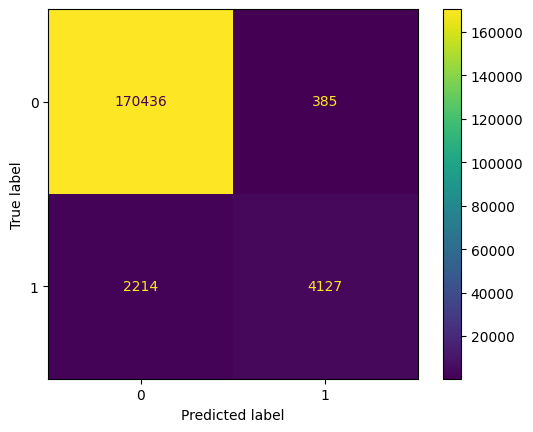

In [60]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()
plt.show()

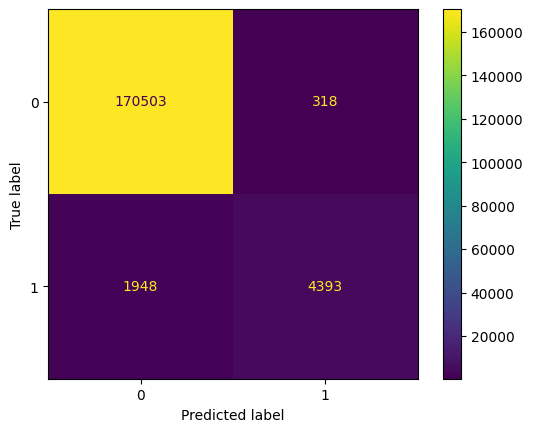

In [59]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()
plt.show()

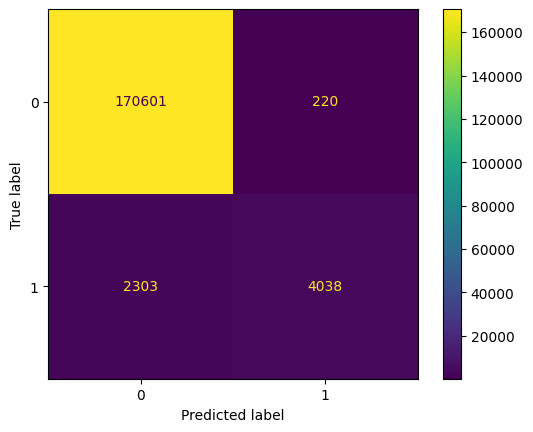

In [68]:
cm = confusion_matrix(y_test, predictions, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()
plt.show()

## Predicting on Test Dataset

In [69]:
y_preds = model.predict_proba(test)[:,1]

In [70]:
y_preds

array([5.0893035e-05, 1.7253520e-04, 3.6551367e-04, ..., 7.4924077e-03,
       5.6054099e-03, 1.2545669e-03], dtype=float32)

In [71]:
sub['isFraud'] = y_preds

In [72]:
sub

,TransactionID,isFraud
0,3663549,0.000051
1,3663550,0.000173
2,3663551,0.000366
3,3663552,0.000059
4,3663553,0.000155
...,...,...
506686,4170235,0.002282
506687,4170236,0.000354
506688,4170237,0.007492
506689,4170238,0.005605


In [73]:
sub.to_csv('sub_FE.csv', index=False)